# Sistem Rekomendasi Pemain Berbasis Touch Map

Notebook ini membandingkan dua pendekatan rekomendasi pemain berdasarkan pola sentuhan di lapangan:

- **Metode utama:** spatial grid, CNN encoder dengan self-supervised contrastive learning, embedding pemain, lalu cosine similarity.
- **Baseline:** spatial grid yang diratakan menjadi vektor, lalu cosine similarity tanpa proses SSL.
- **Evaluasi:** perbandingan intra-player dan inter-player similarity, serta consistency@5 berdasarkan role dan posisi spesifik.
- **Interpretasi:** heatmap digunakan untuk membaca pola area sentuhan dari pemain acuan dan kandidat rekomendasi.

Baseline dipakai sebagai pembanding agar kontribusi SSL dapat dibahas lebih jelas. Output utama aplikasi tetap berasal dari embedding SSL.


## 0. Instalasi Dependency

Jalankan cell ini satu kali jika environment belum memiliki library yang dibutuhkan.


In [1]:
# Jalankan sekali jika dependency belum tersedia.
%pip install -q numpy pandas matplotlib torch openpyxl


You should consider upgrading via the '/Users/el/Downloads/streamlit_player_recommender/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 1. Import Library dan Konfigurasi Awal


In [2]:
from pathlib import Path
import random
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import display

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name.upper() == "NOTEBOOK":
    PROJECT_DIR = PROJECT_DIR.parent

DATASET_DIR = PROJECT_DIR / "DATASET"
if not DATASET_DIR.exists():
    DATASET_DIR = PROJECT_DIR / "dataset"

DATASETS = {
    "1liga": [DATASET_DIR / "touch_events_1liga.csv"],
    "5liga": [DATASET_DIR / "touch_events_5liga.csv"],
}

SEARCH_DIRS = [DATASET_DIR]

POSITION_XLSX_PATH = DATASET_DIR / "LWRW.xlsx"
POSITION_SHEET_NAME = "Combined Players"

OUTPUT_DIR = PROJECT_DIR / "outputs_ssl_vs_rawgrid_position_proxy"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
GRID_X = 16
GRID_Y = 12
MIN_TOUCHES_PER_SAMPLE = 8

BATCH_SIZE = 64
EPOCHS = 40              # Maksimal epoch. Model akhir tetap dipilih dari best validation loss.
LR = 8e-4                # Sedikit lebih kecil agar update lebih stabil.
WEIGHT_DECAY = 1e-4      # Regularisasi AdamW untuk mengurangi overfitting.
TEMPERATURE = 0.2        # Temperature lebih halus daripada 0.1 untuk contrastive logits.
VAL_RATIO = 0.2
PATIENCE = 5             # Early stopping jika validation loss tidak membaik.
MIN_DELTA = 1e-4         # Perbaikan minimum agar dianggap membaik.
DROPOUT_RATE = 0.2       # Dropout di encoder/projection agar tidak terlalu menghafal.
EMBED_DIM = 64
TOP_K = 10

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

INCLUDE_DUELS = True
FULL_EVENT_WHITELIST = {"Pass", "Shot", "Free Kick", "Others on the ball"}
DUEL_SUBEVENT_WHITELIST = {"Air duel", "Ground attacking duel"}

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)


## 2. Cleaning Nama Pemain
Bagian ini mengatasi nama CSV yang masih berupa unicode escape, misalnya `M. \\u00d6zil`.


In [3]:
def clean_player_name(name):
    if pd.isna(name):
        return name

    s = str(name)

    # Decode unicode escape text if present.
    try:
        if "\\u" in s or "\\x" in s:
            s = s.encode("utf-8").decode("unicode_escape")
    except Exception:
        pass

    # Fix mojibake (can be double-encoded).
    for _ in range(3):
        try:
            if "Ã" in s or "Â" in s:
                s_new = s.encode("latin1").decode("utf-8")
                if s_new == s:
                    break
                s = s_new
            else:
                break
        except Exception:
            break

    # Remove hidden/invalid chars that often appear as boxes.
    s = (
        s.replace("­", "")
         .replace("​", "")
         .replace("﻿", "")
         .replace("�", "")
         .replace("\u00ad", "")
    )

    s = unicodedata.normalize("NFC", s)
    s = " ".join(s.strip().split())
    return s


def make_name_key(name):
    if pd.isna(name):
        return ""
    s = clean_player_name(name)
    s = unicodedata.normalize("NFKD", str(s))
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower()
    s = s.replace("ł", "l")
    s = "".join(ch if (ch.isalnum() or ch.isspace()) else " " for ch in s)
    s = " ".join(s.split())
    return s


### 2b. Perbaikan Mojibake Nama Pemain

Beberapa file CSV dapat menghasilkan nama seperti `M. ÃÂzil` atau `P. GroÃÂ`. Cell ini memperbaiki encoding agar output tabel dan heatmap lebih layak untuk laporan skripsi.


In [4]:
def fix_mojibake_name(x):
    """Perbaiki teks mojibake seperti 'J. RodrÃguez' -> 'J. Rodríguez'."""
    return clean_player_name(x)


def clean_display_names_inplace(df):
    """Membersihkan kolom nama untuk tampilan tanpa mengubah id."""
    if df is None:
        return df
    for col in ["player_name", "team_name", "player_name_raw"]:
        if col in df.columns:
            df[col] = df[col].apply(clean_player_name)
    return df


## 3. Load Metadata Posisi Detail dari Excel

Bagian ini membaca Excel posisi detail dan membuat lookup yang kuat. Matching dilakukan dengan prioritas:

1. `player_id`, karena paling aman jika ID sama antara CSV dan Excel.
2. fallback `player_name` yang sudah dibersihkan dari unicode/aksen.

Metadata posisi hanya dipakai untuk informasi output dan sanity check, bukan target utama model.


In [5]:
# Tujuan: mencegah specific_position / position_status menjadi Unknown
# karena perbedaan nama kolom, tipe player_id, atau format nama pemain.

import re


def normalize_colname(col):
    """Normalisasi nama kolom Excel agar mudah dideteksi."""
    col = str(col).strip().lower()
    col = col.replace(" ", "_").replace("-", "_")
    col = re.sub(r"[^a-z0-9_]", "", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_")


def resolve_existing_file(path_or_names, search_dirs=None, extensions=None):
    """Cari file dari nama/path langsung, SEARCH_DIRS, dan pencarian rekursif terbatas."""
    if search_dirs is None:
        search_dirs = SEARCH_DIRS

    if isinstance(path_or_names, (str, Path)):
        candidates = [path_or_names]
    else:
        candidates = list(path_or_names)

    # Cek langsung dan relatif terhadap search dirs
    for cand in candidates:
        cand_path = Path(cand)
        if cand_path.exists():
            return cand_path
        for d in search_dirs:
            try:
                p = Path(d) / cand_path
                if p.exists():
                    return p
            except Exception:
                pass

    # Cek rekursif berdasarkan nama file
    for cand in candidates:
        cand_name = Path(cand).name
        for d in search_dirs:
            try:
                if Path(d).exists():
                    matches = list(Path(d).rglob(cand_name))
                    if matches:
                        return matches[0]
            except Exception:
                pass

    # Fallback cari berdasarkan extension
    if extensions:
        for d in search_dirs:
            try:
                if Path(d).exists():
                    for ext in extensions:
                        matches = list(Path(d).rglob(f"*{ext}"))
                        if matches:
                            return matches[0]
            except Exception:
                pass

    return None


def pick_col(df, candidates):
    """Ambil kolom pertama yang cocok dari daftar kandidat."""
    cols = df.columns.tolist()
    for c in candidates:
        if c in cols:
            return c
    return None


def clean_position_value(x):
    """Bersihkan nilai posisi supaya empty/nan tidak dianggap posisi valid."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.lower() in {"", "nan", "none", "null", "unknown"}:
        return np.nan
    return s


def player_id_key(series):
    """Samakan format player_id, misalnya 38021.0 -> 38021."""
    return (
        series.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
    )


def load_position_lookup(
    path=POSITION_XLSX_PATH,
    sheet_name=POSITION_SHEET_NAME,
    verbose=True,
):
    xlsx_candidates = [path, DATASET_DIR / "LWRW.xlsx"]

    xlsx_path = resolve_existing_file(xlsx_candidates, SEARCH_DIRS, extensions=[".xlsx"])
    if xlsx_path is None:
        print("File Excel posisi detail tidak ditemukan. specific_position akan diisi Unknown.")
        return None

    if verbose:
        print("File Excel posisi detail ditemukan:", xlsx_path)

    # Baca sheet yang ditentukan, fallback sheet pertama
    try:
        pos_raw = pd.read_excel(xlsx_path, sheet_name=sheet_name)
    except Exception:
        pos_raw = pd.read_excel(xlsx_path)

    if verbose:
        print("\nKolom Excel asli:")
        print(pos_raw.columns.tolist())
        display(pos_raw.head())

    pos = pos_raw.copy()
    pos.columns = [normalize_colname(c) for c in pos.columns]

    if verbose:
        print("\nKolom Excel setelah normalisasi:")
        print(pos.columns.tolist())

    excel_player_id_col = pick_col(pos, [
        "player_id", "id", "sofifa_id", "playerid", "player_id_key", "wy_id", "wyscout_id"
    ])
    excel_name_col = pick_col(pos, [
        "player_name", "name", "short_name", "long_name", "full_name", "nama", "nama_pemain", "player"
    ])
    excel_specific_position_col = pick_col(pos, [
        "specific_position", "detail_position", "detailed_position", "position_detail",
        "posisi_detail", "posisi_spesifik", "posisi", "position", "player_positions",
        "player_position", "primary_position", "main_position"
    ])
    excel_position_status_col = pick_col(pos, [
        "position_status", "status_position", "status_posisi", "position_category", "position_group"
    ])

    if verbose:
        print("\nKolom yang terdeteksi dari Excel:")
        print("player_id column        :", excel_player_id_col)
        print("player_name column      :", excel_name_col)
        print("specific_position column:", excel_specific_position_col)
        print("position_status column  :", excel_position_status_col)

    if excel_player_id_col is None and excel_name_col is None:
        print("Excel tidak memiliki kolom player_id maupun player_name yang bisa dideteksi.")
        return None

    if excel_specific_position_col is None:
        print("Kolom specific_position tidak terdeteksi. Nilai posisi detail akan Unknown.")

    keep = []
    if excel_player_id_col: keep.append(excel_player_id_col)
    if excel_name_col: keep.append(excel_name_col)
    if excel_specific_position_col: keep.append(excel_specific_position_col)
    if excel_position_status_col: keep.append(excel_position_status_col)

    # Kolom tambahan yang mungkin berguna untuk output/diagnostik
    for c in ["role_name", "transfermarkt_raw_position", "transfermarkt_url", "team_name"]:
        if c in pos.columns and c not in keep:
            keep.append(c)

    lookup = pos[keep].copy()
    rename = {}
    if excel_player_id_col: rename[excel_player_id_col] = "player_id_excel"
    if excel_name_col: rename[excel_name_col] = "player_name_excel"
    if excel_specific_position_col: rename[excel_specific_position_col] = "specific_position_excel"
    if excel_position_status_col: rename[excel_position_status_col] = "position_status_excel"
    lookup = lookup.rename(columns=rename)

    if "player_id_excel" in lookup.columns:
        lookup["player_id_key"] = player_id_key(lookup["player_id_excel"])
    if "player_name_excel" in lookup.columns:
        lookup["player_name_clean"] = lookup["player_name_excel"].apply(clean_player_name)
        lookup["player_name_key"] = lookup["player_name_clean"].apply(make_name_key)

    if "specific_position_excel" not in lookup.columns:
        lookup["specific_position_excel"] = np.nan
    else:
        lookup["specific_position_excel"] = lookup["specific_position_excel"].apply(clean_position_value)

    if "position_status_excel" not in lookup.columns:
        lookup["position_status_excel"] = np.nan
    else:
        lookup["position_status_excel"] = lookup["position_status_excel"].apply(clean_position_value)

    # Kalau position_status kosong, bentuk sederhana dari role/detail
    # status ini hanya metadata output, bukan ground truth utama.
    missing_status = lookup["position_status_excel"].isna()
    if missing_status.any():
        lookup.loc[missing_status, "position_status_excel"] = lookup.loc[missing_status, "specific_position_excel"].apply(
            lambda x: "HAS_DETAIL_POSITION" if pd.notna(x) else np.nan
        )

    lookup = lookup.drop_duplicates().reset_index(drop=True)

    if verbose:
        print("\nPosition lookup shape:", lookup.shape)
        display(lookup.head())
        print("\nDistribusi specific_position di Excel:")
        display(lookup["specific_position_excel"].value_counts(dropna=False).head(20))

    return lookup


position_lookup = load_position_lookup()


File Excel posisi detail ditemukan: /Users/el/Downloads/streamlit_player_recommender/Football-Player-Scouting-Recommendation-System/DATASET/LWRW.xlsx

Kolom Excel asli:
['player_id', 'total_minutes', 'n_matches', 'player_name', 'full_name', 'role_name', 'transfeRWarkt_url', 'transfeRWarkt_raw_position', 'specific_position', 'position_status', 'Column Search']


,player_id,total_minutes,n_matches,player_name,full_name,role_name,transfeRWarkt_url,transfeRWarkt_raw_position,specific_position,position_status,Column Search
0,36.0,1176,14,T. Alderweireld,Toby Alderweireld,Defender,https://www.transfeRWarkt.com/toby-alderweirel...,Defender - Centre-Back,CB,DEF_NEEDS_DETAIL,Alderweireld
1,48.0,3204,36,J. Vertonghen,Jan Vertonghen,Defender,https://www.transfeRWarkt.com/jan-vertonghen/p...,Defender - Centre-Back,CB,DEF_NEEDS_DETAIL,Vertonghen
2,54.0,3226,37,C. Eriksen,Christian Dannemann Eriksen,Midfielder,https://www.transfeRWarkt.com/christian-erikse...,Midfield - Attacking Midfield,CAM,MID_NEEDS_DETAIL,Eriksen
3,NaN,1396,16,R. Klavan,Ragnar Klavan,Defender,NaN,NaN,CB,DEF_NEEDS_DETAIL,Klavan
4,77.0,2250,25,N. Moisander,Niklas Moisander,Defender,https://www.transfeRWarkt.com/niklas-moisander...,Defender - Centre-Back,CB,DEF_NEEDS_DETAIL,Moisander



Kolom Excel setelah normalisasi:
['player_id', 'total_minutes', 'n_matches', 'player_name', 'full_name', 'role_name', 'transferwarkt_url', 'transferwarkt_raw_position', 'specific_position', 'position_status', 'column_search']

Kolom yang terdeteksi dari Excel:
player_id column        : player_id
player_name column      : player_name
specific_position column: specific_position
position_status column  : position_status

Position lookup shape: (1822, 8)


,player_id_excel,player_name_excel,specific_position_excel,position_status_excel,role_name,player_id_key,player_name_clean,player_name_key
0,36.0,T. Alderweireld,CB,DEF_NEEDS_DETAIL,Defender,36,T. Alderweireld,t alderweireld
1,48.0,J. Vertonghen,CB,DEF_NEEDS_DETAIL,Defender,48,J. Vertonghen,j vertonghen
2,54.0,C. Eriksen,CAM,MID_NEEDS_DETAIL,Midfielder,54,C. Eriksen,c eriksen
3,NaN,R. Klavan,CB,DEF_NEEDS_DETAIL,Defender,nan,R. Klavan,r klavan
4,77.0,N. Moisander,CB,DEF_NEEDS_DETAIL,Defender,77,N. Moisander,n moisander



Distribusi specific_position di Excel:


specific_position_excel
CB     348
ST     266
CM     256
RB     157
CDM    157
RW     151
LB     148
LW     146
GK     124
CAM     69
Name: count, dtype: int64

## 4. Load dan Preprocessing Dataset
Fokus penelitian adalah touch map spasial berbasis `x_coord` dan `y_coord`.


In [6]:
def resolve_existing_path(path_or_names, dataset_name=None):
    """
    Mencari file dari string path atau daftar alternatif nama file.
    Ini mencegah error ketika file sebenarnya ada, tetapi folder kerja notebook berbeda.
    """
    if isinstance(path_or_names, (str, Path)):
        candidates = [path_or_names]
    else:
        candidates = list(path_or_names)

    # 1) Cek langsung dan di SEARCH_DIRS
    for cand in candidates:
        cand_path = Path(cand)
        if cand_path.exists():
            return cand_path

        for d in SEARCH_DIRS:
            try:
                p = d / cand_path
                if p.exists():
                    return p
            except Exception:
                pass

    # 2) Pencarian rekursif terbatas berdasarkan nama file
    for cand in candidates:
        cand_name = Path(cand).name
        for d in SEARCH_DIRS:
            try:
                if d.exists():
                    matches = list(d.rglob(cand_name))
                    if matches:
                        return matches[0]
            except Exception:
                pass

    # 3) Fallback: cari CSV yang mengandung keyword dataset, misalnya 1liga / 5liga
    if dataset_name is not None:
        keywords = []
        if "1" in str(dataset_name):
            keywords = ["1liga", "1_liga", "filtered"]
        elif "5" in str(dataset_name):
            keywords = ["5liga", "5_liga"]

        for d in SEARCH_DIRS:
            try:
                if d.exists():
                    for csv_file in d.rglob("*.csv"):
                        name = csv_file.name.lower()
                        if any(k in name for k in keywords):
                            return csv_file
            except Exception:
                pass

    return None


def merge_position_detail(df, position_lookup, verbose=False):
    """
    Merge detail posisi ke dataframe event/sample.
    Prioritas:
    1. player_id_key
    2. player_name_key
    """
    df = df.copy()

    for c in [
        "specific_position", "position_status", "transfermarkt_raw_position", "transfermarkt_url",
        "specific_position_x", "specific_position_y", "position_status_x", "position_status_y",
    ]:
        if c in df.columns:
            df = df.drop(columns=[c])

    if "player_name" in df.columns:
        df["player_name"] = df["player_name"].apply(clean_player_name)
        df["player_name_key"] = df["player_name"].apply(make_name_key)
    else:
        df["player_name_key"] = ""

    if "player_id" in df.columns:
        df["player_id_key"] = player_id_key(df["player_id"])
    else:
        df["player_id_key"] = ""

    if position_lookup is None or len(position_lookup) == 0:
        df["specific_position"] = "Unknown"
        df["position_status"] = "Unknown"
        return df

    if "player_id_key" in position_lookup.columns:
        keep_cols = ["player_id_key", "specific_position_excel", "position_status_excel"]
        for extra in ["transfermarkt_raw_position", "transfermarkt_url"]:
            if extra in position_lookup.columns:
                keep_cols.append(extra)

        pos_by_id = (
            position_lookup[keep_cols]
            .dropna(subset=["player_id_key"])
            .drop_duplicates(subset=["player_id_key"])
        )
        df = df.merge(pos_by_id, on="player_id_key", how="left")
    else:
        df["specific_position_excel"] = np.nan
        df["position_status_excel"] = np.nan

    df["specific_position"] = df["specific_position_excel"] if "specific_position_excel" in df.columns else np.nan
    df["position_status"] = df["position_status_excel"] if "position_status_excel" in df.columns else np.nan

    if "player_name_key" in position_lookup.columns:
        keep_cols = ["player_name_key", "specific_position_excel", "position_status_excel"]
        for extra in ["transfermarkt_raw_position", "transfermarkt_url"]:
            if extra in position_lookup.columns:
                keep_cols.append(extra)

        pos_by_name = (
            position_lookup[keep_cols]
            .dropna(subset=["player_name_key"])
            .drop_duplicates(subset=["player_name_key"])
            .rename(columns={
                "specific_position_excel": "specific_position_by_name",
                "position_status_excel": "position_status_by_name",
                "transfermarkt_raw_position": "transfermarkt_raw_position_by_name",
                "transfermarkt_url": "transfermarkt_url_by_name",
            })
        )
        df = df.merge(pos_by_name, on="player_name_key", how="left")

        if "specific_position_by_name" in df.columns:
            df["specific_position"] = df["specific_position"].fillna(df["specific_position_by_name"])
        if "position_status_by_name" in df.columns:
            df["position_status"] = df["position_status"].fillna(df["position_status_by_name"])

        for base in ["transfermarkt_raw_position", "transfermarkt_url"]:
            by_name = f"{base}_by_name"
            if base not in df.columns:
                df[base] = np.nan
            if by_name in df.columns:
                df[base] = df[base].fillna(df[by_name])

    df["specific_position"] = df["specific_position"].apply(clean_position_value).fillna("Unknown")
    df["position_status"] = df["position_status"].apply(clean_position_value).fillna("Unknown")

    drop_cols = [
        "specific_position_excel", "position_status_excel",
        "specific_position_by_name", "position_status_by_name",
        "transfermarkt_raw_position_by_name", "transfermarkt_url_by_name",
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

    if verbose:
        print("Merge posisi detail selesai.")
        print("Unknown specific_position:", (df["specific_position"] == "Unknown").mean())
        display(df[[c for c in ["player_id", "player_name", "role_name", "specific_position", "position_status"] if c in df.columns]].drop_duplicates().head(20))

    return df


def _resolve_half_col(df):
    for c in ["match_period", "period", "half", "match_half"]:
        if c in df.columns:
            return c
    return None


def _to_half_number(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if s in {"1", "1h", "h1", "first", "1st", "first half"}:
        return 1
    if s in {"2", "2h", "h2", "second", "2nd", "second half"}:
        return 2
    try:
        n = int(float(s))
        if n in {1, 2}:
            return n
    except Exception:
        pass
    return np.nan


def _normalise_role_label(v):
    s = str(v).strip().lower()
    if "goalkeeper" in s:
        return "Goalkeeper"
    if "defender" in s:
        return "Defender"
    if "midfielder" in s:
        return "Midfielder"
    if "forward" in s or "striker" in s or "winger" in s:
        return "Forward"
    return "Unknown"


def _attacking_touch_mask(df):
    event = df["event_name"].astype(str).str.strip().str.lower() if "event_name" in df.columns else pd.Series("", index=df.index)
    subevent = df["subevent_name"].astype(str).str.strip().str.lower() if "subevent_name" in df.columns else pd.Series("", index=df.index)

    attacking_events = {"pass", "shot", "free kick", "others on the ball"}
    attacking_subevents = {
        "simple pass", "head pass", "high pass", "smart pass", "launch", "cross",
        "shot", "free kick", "free kick shot", "free kick cross", "corner", "penalty",
        "goal kick", "throw in", "touch", "acceleration", "ground attacking duel", "air duel",
    }
    defensive_subevents = {"clearance", "ground defending duel", "ground loose ball duel"}

    return (event.isin(attacking_events) | subevent.isin(attacking_subevents)) & ~subevent.isin(defensive_subevents)


def _infer_direction_by_role(out, team_half, min_players=4, min_roles=2, margin=2.0):
    """
    Pilih orientasi per tim-babak dengan membandingkan kecocokan median x pemain
    terhadap ekspektasi role setelah semua tim menyerang ke kanan.
    """
    role_anchor_x = {
        "Goalkeeper": 10.0,
        "Defender": 30.0,
        "Midfielder": 52.0,
        "Forward": 72.0,
    }
    if "role_name" not in out.columns or "player_id" not in out.columns:
        return pd.DataFrame(columns=team_half + ["attacking_right", "direction_method", "direction_score_gap"])

    tmp = out.copy()
    tmp["_role_norm"] = tmp["role_name"].apply(_normalise_role_label)
    tmp = tmp[tmp["_role_norm"].isin(role_anchor_x)].copy()
    if len(tmp) == 0:
        return pd.DataFrame(columns=team_half + ["attacking_right", "direction_method", "direction_score_gap"])

    player_half = (
        tmp.groupby(team_half + ["player_id", "_role_norm"], dropna=False)
        .agg(median_x=("x_coord", "median"), n_events=("x_coord", "size"))
        .reset_index()
    )
    player_half = player_half[player_half["n_events"] >= 3].copy()
    player_half["expected_x"] = player_half["_role_norm"].map(role_anchor_x)

    rows = []
    for keys, g in player_half.groupby(team_half, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        n_players = int(g["player_id"].nunique())
        n_roles = int(g["_role_norm"].nunique())
        if n_players < min_players or n_roles < min_roles:
            continue

        weights = np.sqrt(g["n_events"].to_numpy(dtype=float))
        x = g["median_x"].to_numpy(dtype=float)
        expected = g["expected_x"].to_numpy(dtype=float)
        direct_error = np.average(np.abs(x - expected), weights=weights)
        mirror_error = np.average(np.abs((100.0 - x) - expected), weights=weights)
        gap = float(mirror_error - direct_error)

        # True berarti koordinat saat ini sudah menyerang ke kanan.
        # False berarti perlu mirror x agar sesuai struktur role sepak bola.
        if abs(gap) < margin:
            continue
        row = dict(zip(team_half, keys))
        row.update({
            "attacking_right": bool(gap > 0),
            "direction_method": "role_shape",
            "direction_score_gap": gap,
        })
        rows.append(row)

    return pd.DataFrame(rows, columns=team_half + ["attacking_right", "direction_method", "direction_score_gap"])


def _infer_direction_by_team_median(out, team_half):
    attack_mask = _attacking_touch_mask(out)
    if "role_name" in out.columns:
        non_gk_mask = ~out["role_name"].astype(str).str.contains("goalkeeper", case=False, na=False)
    else:
        non_gk_mask = pd.Series(True, index=out.index)

    infer_df = out[attack_mask & non_gk_mask].copy()
    if len(infer_df) == 0:
        infer_df = out[non_gk_mask].copy()
    if len(infer_df) == 0:
        infer_df = out.copy()

    grp = infer_df.groupby(team_half, dropna=False)["x_coord"].median().reset_index(name="median_x")
    grp["attacking_right"] = pd.Series(pd.NA, index=grp.index, dtype="object")
    grp["direction_method"] = "team_median"
    grp["direction_score_gap"] = np.nan

    for (_, half), gmh in grp.groupby(["match_id", "_half_norm"], dropna=False):
        if len(gmh) >= 2:
            median_center = gmh["median_x"].median()
            grp.loc[gmh.index, "attacking_right"] = gmh["median_x"] >= median_center
        else:
            grp.loc[gmh.index, "attacking_right"] = gmh["median_x"] >= 50.0

    return grp[team_half + ["attacking_right", "direction_method", "direction_score_gap"]]


def normalize_attacking_direction(df, verbose=True, keep_audit_cols=False):
    """
    Menyeragamkan arah serang ke kanan (x meningkat ke kanan) sebelum agregasi grid.

    Strategi utama:
    1) Inferensi per (match_id, team_id, half) memakai bentuk role pemain.
       Setelah normal, GK/defender cenderung di x kecil, midfielder di tengah,
       forward di x besar. Kandidat direct vs mirror dipilih dari error terkecil.
    2) Jika role tidak cukup lengkap, fallback ke median x tim relatif terhadap
       lawan pada match-half yang sama.
    3) Tim-babak yang menyerang ke kiri di-flip dengan x' = 100 - x.
    4) y dibalik sekali agar konvensi visual tetap: sisi kanan lapangan di bawah
       pada plotting yang dipakai notebook ini.
    """
    out = df.copy()

    for col in ["x_coord", "y_coord"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    if "minute" in out.columns:
        out["minute"] = pd.to_numeric(out["minute"], errors="coerce")

    out = out[out["x_coord"].notna() & out["y_coord"].notna()].copy()

    half_col = _resolve_half_col(out)
    if half_col is None:
        if "minute" in out.columns:
            out["_half_norm"] = np.where(out["minute"].fillna(0) <= 45, 1, 2)
        else:
            out["_half_norm"] = 1
    else:
        out["_half_norm"] = out[half_col].apply(_to_half_number)
        if "minute" in out.columns:
            minute_half = pd.Series(np.where(out["minute"].fillna(0) <= 45, 1, 2), index=out.index)
            out["_half_norm"] = out["_half_norm"].where(out["_half_norm"].notna(), minute_half)
        out["_half_norm"] = out["_half_norm"].fillna(1)
    out["_half_norm"] = pd.to_numeric(out["_half_norm"], errors="coerce").fillna(1).astype(int)

    team_half = ["match_id", "team_id", "_half_norm"]
    role_dir = _infer_direction_by_role(out, team_half)
    median_dir = _infer_direction_by_team_median(out, team_half)

    direction = median_dir.merge(
        role_dir,
        on=team_half,
        how="left",
        suffixes=("_median", "_role"),
    )
    direction["attacking_right"] = direction["attacking_right_role"].combine_first(
        direction["attacking_right_median"]
    )
    direction["direction_method"] = direction["direction_method_role"].where(
        direction["direction_method_role"].notna(),
        direction["direction_method_median"],
    )
    direction["direction_score_gap"] = direction["direction_score_gap_role"].where(
        direction["direction_score_gap_role"].notna(),
        direction["direction_score_gap_median"],
    )
    direction = direction[team_half + ["attacking_right", "direction_method", "direction_score_gap"]]

    out = out.merge(direction, on=team_half, how="left")
    out["attacking_right"] = out["attacking_right"].combine_first(pd.Series(True, index=out.index)).astype(bool)
    out["direction_method"] = out["direction_method"].fillna("default_right")

    need_flip = ~out["attacking_right"]
    out["direction_flipped_x"] = need_flip
    out.loc[need_flip, "x_coord"] = 100.0 - out.loc[need_flip, "x_coord"]

    # Konvensi tetap (attacking -> kanan): RW bawah, LW atas.
    out["y_coord"] = 100.0 - out["y_coord"]

    out["x_coord"] = out["x_coord"].clip(0, 100)
    out["y_coord"] = out["y_coord"].clip(0, 100)

    if verbose:
        flip_ratio = float(need_flip.mean()) if len(out) > 0 else 0.0
        method_counts = out["direction_method"].value_counts(dropna=False).to_dict()
        print(f"[DIR-NORM] Event di-flip x: {flip_ratio:.2%} ({int(need_flip.sum())}/{len(out)})")
        print(f"[DIR-NORM] Metode inferensi: {method_counts}")

    drop_cols = ["_half_norm", "attacking_right"]
    if not keep_audit_cols:
        drop_cols += ["direction_method", "direction_score_gap", "direction_flipped_x"]
    return out.drop(columns=drop_cols, errors="ignore")


def apply_role_consistency_fix(df, gk_max_x=45.0, verbose=True):
    """Role-based correction after team-half direction normalization."""
    out = df.copy()
    if "role_name" not in out.columns:
        return out

    gk_mask = out["role_name"].astype(str).str.contains("goalkeeper", case=False, na=False)
    if not gk_mask.any():
        return out

    n_fix = 0
    for (pid, mid), g in out[gk_mask].groupby(["player_id", "match_id"], dropna=False):
        if len(g) < 8:
            continue
        med_x = float(g["x_coord"].median())
        if med_x > gk_max_x:
            out.loc[g.index, "x_coord"] = 100.0 - out.loc[g.index, "x_coord"]
            n_fix += 1

    out["x_coord"] = out["x_coord"].clip(0, 100)
    if verbose:
        print(f"[ROLE-FIX] GK player-match flipped: {n_fix}")
    return out


def remove_goalkeeper_rows(df, verbose=True):
    """Hapus baris pemain goalkeeper dari data sebelum agregasi/training."""
    out = df.copy()
    goalkeeper_mask = pd.Series(False, index=out.index)

    for col in ["role_name", "specific_position"]:
        if col in out.columns:
            goalkeeper_mask = goalkeeper_mask | out[col].astype(str).str.strip().str.lower().isin({"gk", "goalkeeper"})

    n_removed = int(goalkeeper_mask.sum())
    if verbose:
        print(f"[FILTER] Baris GK/Goalkeeper dihapus: {n_removed}")

    return out.loc[~goalkeeper_mask].copy()


def load_and_preprocess_dataset(csv_path_or_names, dataset_name, position_lookup=None):
    csv_path = resolve_existing_path(csv_path_or_names, dataset_name=dataset_name)
    if csv_path is None:
        print(f"[SKIP] {dataset_name}: file tidak ditemukan. Kandidat nama/path:")
        if isinstance(csv_path_or_names, (list, tuple)):
            for c in csv_path_or_names:
                print("  -", c)
        else:
            print("  -", csv_path_or_names)
        return None

    print(f"[LOAD] {dataset_name}: {csv_path}")
    df = pd.read_csv(csv_path)

    required_cols = [
        "match_id", "player_id", "team_id", "event_name", "subevent_name",
        "minute", "x_coord", "y_coord", "player_name", "role_name", "team_name"
    ]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        print("Kolom yang tersedia:")
        print(df.columns.tolist())
        raise ValueError(f"Dataset {dataset_name} kehilangan kolom wajib: {missing_cols}")

    df["dataset_name"] = dataset_name
    df["player_name_raw"] = df["player_name"]
    df["player_name"] = df["player_name"].apply(clean_player_name)
    df["player_name_key"] = df["player_name"].apply(make_name_key)

    df = merge_position_detail(df, position_lookup)

    event_name = df["event_name"].astype(str)
    subevent_name = df["subevent_name"].astype(str)

    touch_mask = event_name.isin(FULL_EVENT_WHITELIST)
    if INCLUDE_DUELS:
        duel_mask = (event_name == "Duel") & subevent_name.isin(DUEL_SUBEVENT_WHITELIST)
        touch_mask = touch_mask | duel_mask

    df_filtered = df[df["event_name"].notna() & df["subevent_name"].notna()].copy()
    df_filtered = df_filtered[touch_mask]
    df_filtered = df_filtered[
        df_filtered["x_coord"].between(0, 100) &
        df_filtered["y_coord"].between(0, 100)
    ].copy()

    # Core fix: normalize direction BEFORE any grid aggregation.
    df_filtered = normalize_attacking_direction(df_filtered, verbose=True, keep_audit_cols=True)
    df_filtered = apply_role_consistency_fix(df_filtered, gk_max_x=45.0, verbose=True)

    role_map = {
        "defender": "Defender",
        "midfielder": "Midfielder",
        "forward": "Forward",
        "gk": "Goalkeeper",
        "goalkeeper": "Goalkeeper",
    }
    df_filtered["role_name"] = (
        df_filtered["role_name"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(lambda x: role_map.get(x, x.title()))
    )
    df_filtered = remove_goalkeeper_rows(df_filtered, verbose=True)

    keep_cols = [
        "dataset_name", "match_id", "player_id", "team_id", "event_name", "subevent_name", "minute",
        "x_coord", "y_coord", "player_name", "player_name_raw", "role_name", "specific_position",
        "position_status", "team_name", "direction_flipped_x", "direction_method", "direction_score_gap"
    ]
    for extra in ["match_date", "transfermarkt_raw_position", "transfermarkt_url", "home_team_id", "away_team_id", "period", "match_period", "half"]:
        if extra in df_filtered.columns and extra not in keep_cols:
            keep_cols.append(extra)

    df_filtered = df_filtered[keep_cols].copy()

    print(f"Dataset {dataset_name} | events setelah filtering: {len(df_filtered)}")
    print(f"Unique players: {df_filtered['player_id'].nunique()} | matches: {df_filtered['match_id'].nunique()}")

    return df_filtered


## 5. Spatial Encoding Berbasis Grid

Touch map titik x,y dikonversi menjadi matriks grid. Grid dinormalisasi menjadi proporsi agar model fokus pada pola area sentuhan.

### Dokumentasi Normalisasi Arah Serang
Sebelum grid dibuat, seluruh event dinormalisasi ke satu orientasi serang (kiri ke kanan) untuk mencegah heatmap pemain tercampur antara arah serang kanan dan kiri:
1. Event dikelompokkan per `match_id`, `team_id`, dan `half`/`period`.
2. Arah utama diinferensikan dari bentuk role pemain. Setelah arah benar, goalkeeper/defender semestinya dominan di x kecil, midfielder di tengah, dan forward di x besar.
3. Jika data role kurang lengkap, notebook memakai fallback median `x_coord` tim relatif terhadap lawan pada match-half yang sama.
4. Tim-babak yang terdeteksi menyerang ke kiri di-flip ke kanan dengan transformasi `x' = 100 - x`; kolom audit `direction_flipped_x`, `direction_method`, dan `direction_score_gap` disimpan.

Dengan langkah ini, event dari dua arah tidak tercampur saat agregasi, sehingga heatmap sisi kanan/kiri lebih konsisten terhadap peran pemain (misalnya forward tidak terlihat dominan di gawang sendiri).


In [7]:
def build_player_match_grids(df_filtered, dataset_name, grid_x=GRID_X, grid_y=GRID_Y):
    meta_rows = []
    grids = []

    for (player_id, match_id), g in df_filtered.groupby(["player_id", "match_id"], sort=False):
        n_touches = len(g)
        if n_touches < MIN_TOUCHES_PER_SAMPLE:
            continue

        xs = np.clip(g["x_coord"].to_numpy(dtype=float), 0, 100 - 1e-8)
        ys = np.clip(g["y_coord"].to_numpy(dtype=float), 0, 100 - 1e-8)

        x_bin = np.floor(xs / 100.0 * grid_x).astype(int)
        y_bin = np.floor(ys / 100.0 * grid_y).astype(int)

        # Mapping eksplisit: x -> kolom (horizontal), y -> baris (vertikal), origin di bawah kiri saat plot.
        grid = np.zeros((grid_y, grid_x), dtype=np.float32)
        for xb, yb in zip(x_bin, y_bin):
            grid[yb, xb] += 1.0

        if grid.sum() > 0:
            grid = grid / grid.sum()

        row0 = g.iloc[0]
        meta_rows.append({
            "dataset_name": dataset_name,
            "player_id": int(player_id),
            "match_id": int(match_id),
            "team_id": int(row0["team_id"]),
            "player_name": clean_player_name(row0["player_name"]),
            "player_name_raw": clean_player_name(row0.get("player_name_raw", row0["player_name"])),
            "role_name": row0["role_name"],
            "specific_position": row0.get("specific_position", "Unknown"),
            "position_status": row0.get("position_status", "Unknown"),
            "team_name": clean_player_name(row0["team_name"]),
            "n_touches": n_touches,
            "minute_min": float(g["minute"].min()),
            "minute_max": float(g["minute"].max()),
            "match_date": row0["match_date"] if "match_date" in g.columns else pd.NaT,
        })
        grids.append(grid)

    meta = pd.DataFrame(meta_rows)
    meta = clean_display_names_inplace(meta)
    X = np.stack(grids) if grids else np.empty((0, grid_y, grid_x), dtype=np.float32)
    return meta, X


if "datasets_filtered" not in globals() or not isinstance(datasets_filtered, dict) or len(datasets_filtered) == 0:
    datasets_filtered = {}
    for dataset_name, csv_candidates in DATASETS.items():
        datasets_filtered[dataset_name] = load_and_preprocess_dataset(
            csv_candidates,
            dataset_name=dataset_name,
            position_lookup=position_lookup,
        )

dataset_artifacts = {}

for dataset_name, df_f in datasets_filtered.items():
    if df_f is None or len(df_f) == 0:
        print(f"[SKIP] Dataset {dataset_name} tidak tersedia atau kosong.")
        continue

    meta, X = build_player_match_grids(df_f, dataset_name)
    if len(meta) == 0 or len(X) == 0:
        print(f"[SKIP] Dataset {dataset_name} tidak menghasilkan sampel player-match.")
        continue

    dataset_artifacts[dataset_name] = {
        "df_filtered": df_f,
        "meta": meta,
        "X": X,
    }

    print(f"\nDataset {dataset_name}")
    print("Jumlah sample player-match:", len(meta))
    print("Shape grid:", X.shape)
    display(meta.head())

if len(dataset_artifacts) == 0:
    raise FileNotFoundError(
        "Tidak ada dataset yang berhasil diproses. Pastikan CSV hasil pembentukan dataset "
        f"dan file LWRW.xlsx tersedia di folder dataset: {DATASET_DIR}"
    )


[LOAD] 1liga: /Users/el/Downloads/streamlit_player_recommender/Football-Player-Scouting-Recommendation-System/DATASET/touch_events_1liga.csv
[DIR-NORM] Event di-flip x: 0.04% (168/466886)
[DIR-NORM] Metode inferensi: {'role_shape': 465165, 'team_median': 1721}
[ROLE-FIX] GK player-match flipped: 8
[FILTER] Baris GK/Goalkeeper dihapus: 23574
Dataset 1liga | events setelah filtering: 443312
Unique players: 306 | matches: 380
[LOAD] 5liga: /Users/el/Downloads/streamlit_player_recommender/Football-Player-Scouting-Recommendation-System/DATASET/touch_events_5liga.csv
[DIR-NORM] Event di-flip x: 0.08% (1774/2298243)
[DIR-NORM] Metode inferensi: {'role_shape': 2290582, 'team_median': 7661}
[ROLE-FIX] GK player-match flipped: 45
[FILTER] Baris GK/Goalkeeper dihapus: 112797
Dataset 5liga | events setelah filtering: 2185446
Unique players: 1698 | matches: 1826

Dataset 1liga
Jumlah sample player-match: 8065
Shape grid: (8065, 12, 16)


,dataset_name,player_id,match_id,team_id,player_name,player_name_raw,role_name,specific_position,position_status,team_name,n_touches,minute_min,minute_max,match_date
0,1liga,36,2499725,1624,T. Alderweireld,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,117,3.0,92.0,NaT
1,1liga,36,2499737,1624,T. Alderweireld,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,90,1.0,89.0,NaT
2,1liga,36,2499746,1624,T. Alderweireld,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,103,0.0,94.0,NaT
3,1liga,36,2499752,1624,T. Alderweireld,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,71,0.0,89.0,NaT
4,1liga,36,2499766,1624,T. Alderweireld,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,111,1.0,92.0,NaT



Dataset 5liga
Jumlah sample player-match: 41118
Shape grid: (41118, 12, 16)


,dataset_name,player_id,match_id,team_id,player_name,player_name_raw,role_name,specific_position,position_status,team_name,n_touches,minute_min,minute_max,match_date
0,5liga,36,2499725,1624,T. Alderweireld,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,117,3.0,92.0,NaT
1,5liga,36,2499737,1624,T. Alderweireld,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,90,1.0,89.0,NaT
2,5liga,36,2499746,1624,T. Alderweireld,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,103,0.0,94.0,NaT
3,5liga,36,2499752,1624,T. Alderweireld,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,71,0.0,89.0,NaT
4,5liga,36,2499766,1624,T. Alderweireld,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,111,1.0,92.0,NaT


## 5A. Validasi Normalisasi Arah Serang (Sanity Check)

Bagian ini memeriksa normalisasi arah serang sudah benar sebelum pembuatan grid:
1. Membandingkan statistik koordinat sebelum vs sesudah normalisasi.
2. Menampilkan persentase event yang di-flip.
3. Menampilkan visual sebaran titik per tim-babak agar terlihat semua sudah mengarah ke kanan.

Catatan interpretasi:
- Jika normalisasi bekerja baik, distribusi `x_coord` sesudah normalisasi akan lebih konsisten ke arah kanan untuk fase menyerang.
- Persentase flip tidak harus 50%, karena tergantung komposisi event tiap dataset.


Data sudah melewati normalize_attacking_direction; memakai kolom audit yang disimpan.
Dataset: 1liga
Events flipped on x-axis: 0.04% (168/443312)


,direction_method,n_events
0,role_shape,441629
1,team_median,1683


,role_name,median_x_after_norm
0,Defender,37.0
1,Forward,69.0
2,Midfielder,57.0


,stage,n_events,x_mean,x_median,y_mean,y_median
0,normalized,443312,51.445206,53.0,50.219739,50.0
1,normalized_role_median,443312,51.445206,53.0,50.219739,50.0


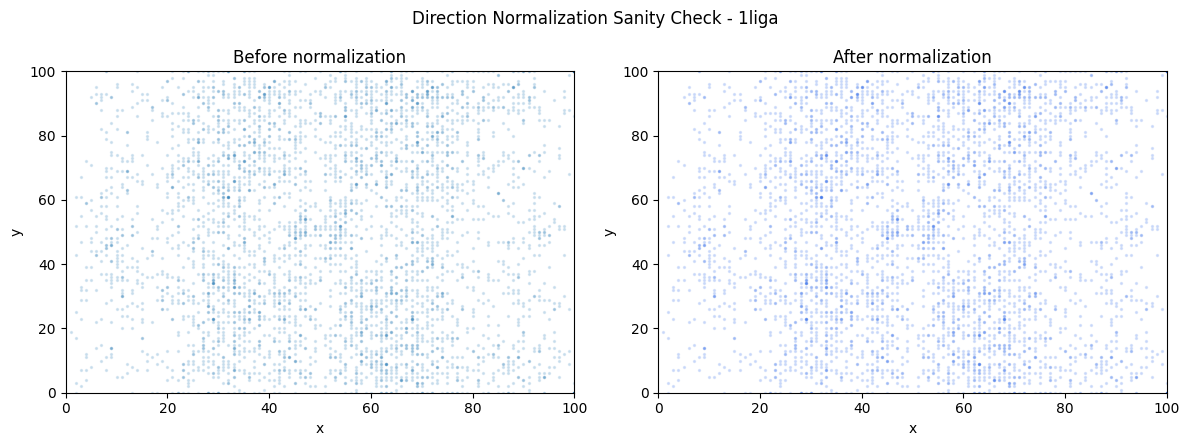

Data sudah melewati normalize_attacking_direction; memakai kolom audit yang disimpan.
Dataset: 5liga
Events flipped on x-axis: 0.08% (1678/2185446)


,direction_method,n_events
0,role_shape,2177960
1,team_median,7486


,role_name,median_x_after_norm
0,Defender,37.0
1,Forward,68.0
2,Midfielder,56.0


,stage,n_events,x_mean,x_median,y_mean,y_median
0,normalized,2185446,50.837226,51.0,50.264,50.0
1,normalized_role_median,2185446,50.837226,51.0,50.264,50.0


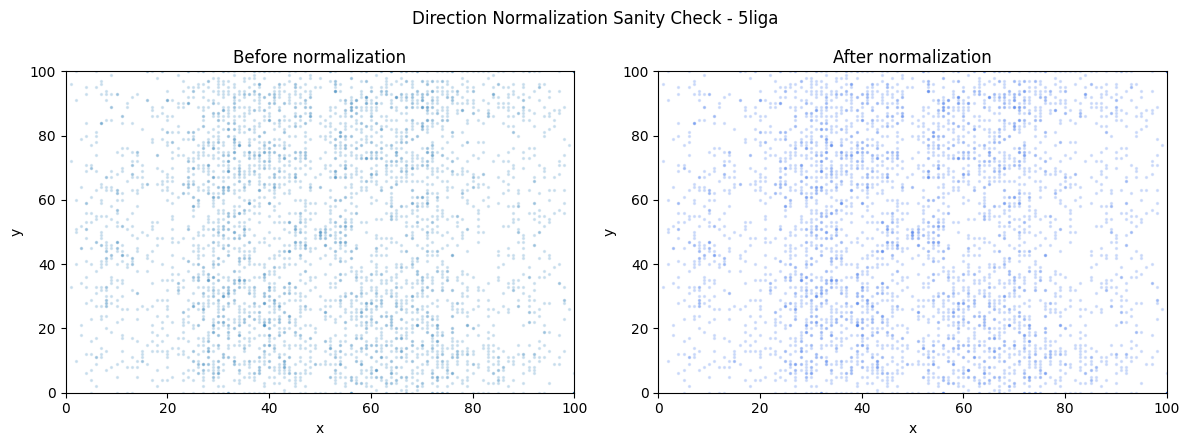

In [8]:
# SANITY CHECK: BEFORE vs AFTER DIRECTION NORMALIZATION

def sanity_check_direction_normalization(df_raw, dataset_name="dataset", n_samples_plot=4000):
    if df_raw is None or len(df_raw) == 0:
        print("Data kosong.")
        return None

    required = ["match_id", "team_id", "x_coord", "y_coord", "event_name", "subevent_name"]
    missing = [c for c in required if c not in df_raw.columns]
    if missing:
        print("Kolom wajib sanity check tidak lengkap:", missing)
        return None

    before = df_raw.copy()
    before["x_coord"] = pd.to_numeric(before["x_coord"], errors="coerce")
    before["y_coord"] = pd.to_numeric(before["y_coord"], errors="coerce")
    before = before[before["x_coord"].between(0,100) & before["y_coord"].between(0,100)].copy()

    already_normalized = "direction_flipped_x" in before.columns
    if already_normalized:
        after = before.copy()
        flip_mask = after["direction_flipped_x"].astype(bool)
        print("Data sudah melewati normalize_attacking_direction; memakai kolom audit yang disimpan.")
    else:
        after = normalize_attacking_direction(before.copy(), verbose=False, keep_audit_cols=True)
        flip_mask = after["direction_flipped_x"].astype(bool)

    stats = pd.DataFrame([
        {
            "stage": "normalized" if already_normalized else "before_norm",
            "n_events": len(before),
            "x_mean": before["x_coord"].mean(),
            "x_median": before["x_coord"].median(),
            "y_mean": before["y_coord"].mean(),
            "y_median": before["y_coord"].median(),
        },
        {
            "stage": "normalized_role_median",
            "n_events": len(after),
            "x_mean": after["x_coord"].mean(),
            "x_median": after["x_coord"].median(),
            "y_mean": after["y_coord"].mean(),
            "y_median": after["y_coord"].median(),
        },
    ])

    print(f"Dataset: {dataset_name}")
    print(f"Events flipped on x-axis: {flip_mask.mean():.2%} ({int(flip_mask.sum())}/{len(flip_mask)})")
    if "direction_method" in after.columns:
        display(after["direction_method"].value_counts(dropna=False).rename_axis("direction_method").reset_index(name="n_events"))
    if "role_name" in after.columns:
        display(after.groupby("role_name", dropna=False)["x_coord"].median().rename("median_x_after_norm").reset_index())
    display(stats)

    # sample points for plotting
    if len(before) > n_samples_plot:
        before_plot = before.sample(n_samples_plot, random_state=42)
        after_plot = after.loc[before_plot.index]
    else:
        before_plot = before
        after_plot = after

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].scatter(before_plot["x_coord"], before_plot["y_coord"], s=2, alpha=0.15)
    axes[0].set_title("Before normalization")
    axes[0].set_xlim(0,100); axes[0].set_ylim(0,100)
    axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

    axes[1].scatter(after_plot["x_coord"], after_plot["y_coord"], s=2, alpha=0.15, color="#2563eb")
    axes[1].set_title("After normalization")
    axes[1].set_xlim(0,100); axes[1].set_ylim(0,100)
    axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

    plt.suptitle(f"Direction Normalization Sanity Check - {dataset_name}")
    plt.tight_layout()
    plt.show()

    return {
        "stats": stats,
        "flip_ratio": float(flip_mask.mean()) if len(flip_mask) else 0.0,
        "n_flipped": int(flip_mask.sum()) if len(flip_mask) else 0,
        "n_events": int(len(flip_mask)),
    }


# Contoh jalan untuk semua dataset yang sudah dipreprocess
if "datasets_filtered" in globals() and isinstance(datasets_filtered, dict):
    sanity_reports = {}
    for dname, ddf in datasets_filtered.items():
        print("="*80)
        sanity_reports[dname] = sanity_check_direction_normalization(ddf, dataset_name=dname)


## 5B. Checklist Kualitas Data dan Orientasi

Checklist sebelum training SSL:
1. `player_name` sudah bersih dari mojibake (contoh: `RodrÃguez` -> `Rodríguez`).
2. `x_coord` dan `y_coord` berada pada rentang [0, 100].
3. Normalisasi arah serang sudah dilakukan sebelum agregasi grid.
4. Tidak ada campuran orientasi dua arah dalam sample player-match yang sama.
5. Mapping grid konsisten: `x -> kolom`, `y -> baris`, origin visual di bawah-kiri.
6. Distribusi `specific_position` tidak didominasi `Unknown`.


In [9]:

def run_data_quality_checks(dataset_artifacts):
    rows = []
    for dname, art in dataset_artifacts.items():
        df = art.get("df_filtered", None)
        meta = art.get("meta", None)
        if df is None or len(df) == 0:
            rows.append({"dataset": dname, "status": "EMPTY"})
            continue

        bad_name_ratio = 0.0
        if "player_name" in df.columns:
            s = df["player_name"].astype(str)
            bad = s.str.contains("Ã|Â|�", regex=True, na=False)
            bad_name_ratio = float(bad.mean())

        xy_ok_ratio = float((df["x_coord"].between(0,100) & df["y_coord"].between(0,100)).mean()) if {"x_coord","y_coord"}.issubset(df.columns) else np.nan

        unknown_pos_ratio = np.nan
        if meta is not None and len(meta) > 0 and "specific_position" in meta.columns:
            unknown_pos_ratio = float((meta["specific_position"].fillna("Unknown") == "Unknown").mean())

        rows.append({
            "dataset": dname,
            "n_events": len(df),
            "bad_name_ratio": bad_name_ratio,
            "xy_in_range_ratio": xy_ok_ratio,
            "unknown_specific_position_ratio": unknown_pos_ratio,
        })

    out = pd.DataFrame(rows)
    display(out)
    return out

if "dataset_artifacts" in globals():
    quality_report = run_data_quality_checks(dataset_artifacts)


,dataset,n_events,bad_name_ratio,xy_in_range_ratio,unknown_specific_position_ratio
0,1liga,443312,0.0,1.0,0.0
1,5liga,2185446,0.0,1.0,0.0


## 5C. Ringkasan Metodologi (Ringkasan Metodologi)

Penelitian ini menggunakan pendekatan Self-Supervised Learning (SSL) pada touch map spasial pemain sepak bola. Proses preprocessing utama dilakukan sebagai berikut:
1. Event sentuhan difilter dari event whitelist dan duel relevan.
2. Nama pemain dinormalisasi untuk mengatasi masalah encoding (mojibake) dan Unicode.
3. Koordinat spasial dinormalisasi ke satu arah serang (kiri ke kanan) agar tidak terjadi pencampuran orientasi home/away dan babak 1/2.
4. Koordinat `x,y` dipetakan menjadi grid 2D terstandar (`x -> kolom`, `y -> baris`), kemudian dinormalisasi menjadi proporsi sentuhan.
5. Grid player-match digunakan sebagai input SSL encoder untuk membangun embedding pemain.
6. Rekomendasi dihitung dengan cosine similarity pada embedding pemain.
7. Heatmap digunakan sebagai explainability visual, bukan sebagai metrik utama evaluasi.


## 6. Visualisasi Spatial Grid / Heatmap
Heatmap hanya sebagai explainability, bukan input smoothing untuk model.


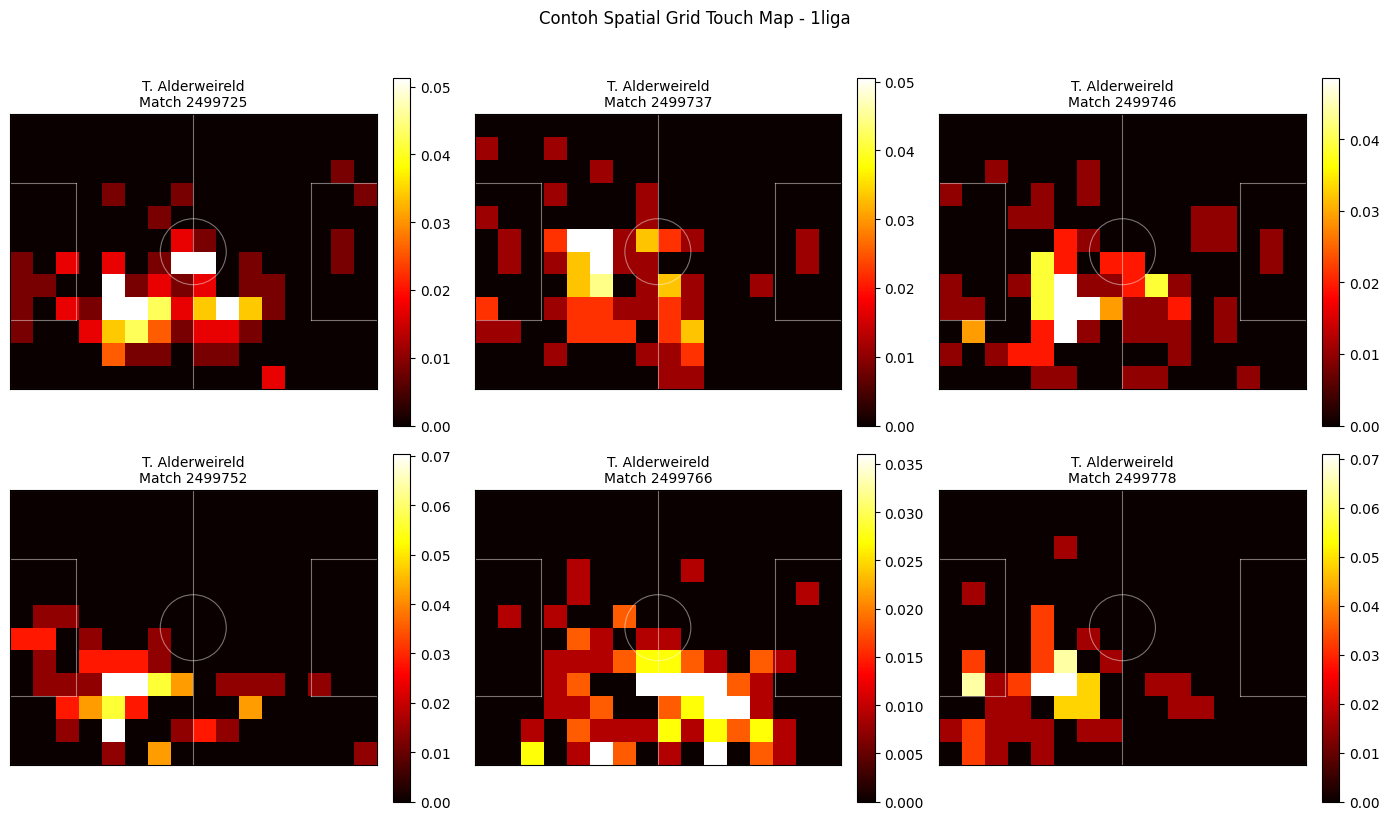

In [10]:
def draw_pitch(ax, field_x=GRID_X, field_y=GRID_Y, line_color="white", alpha=0.45, lw=0.8):
    # Outline
    ax.plot([-0.5, field_x - 0.5], [-0.5, -0.5], color=line_color, alpha=alpha, lw=lw)
    ax.plot([-0.5, field_x - 0.5], [field_y - 0.5, field_y - 0.5], color=line_color, alpha=alpha, lw=lw)
    ax.plot([-0.5, -0.5], [-0.5, field_y - 0.5], color=line_color, alpha=alpha, lw=lw)
    ax.plot([field_x - 0.5, field_x - 0.5], [-0.5, field_y - 0.5], color=line_color, alpha=alpha, lw=lw)

    # Garis tengah
    ax.plot([field_x / 2 - 0.5, field_x / 2 - 0.5], [-0.5, field_y - 0.5], color=line_color, alpha=alpha, lw=lw)

    # Lingkaran tengah
    center_circle = plt.Circle(
        (field_x / 2 - 0.5, field_y / 2 - 0.5),
        radius=min(field_x, field_y) * 0.12,
        fill=False,
        color=line_color,
        alpha=alpha,
        lw=lw
    )
    ax.add_patch(center_circle)

    # Kotak penalti sederhana
    box_h = field_y * 0.5
    y1 = (field_y - box_h) / 2 - 0.5
    y2 = (field_y + box_h) / 2 - 0.5
    left_x = field_x * 0.18 - 0.5
    right_x = field_x * (1 - 0.18) - 0.5

    ax.plot([-0.5, left_x], [y1, y1], color=line_color, alpha=alpha, lw=lw)
    ax.plot([left_x, left_x], [y1, y2], color=line_color, alpha=alpha, lw=lw)
    ax.plot([left_x, -0.5], [y2, y2], color=line_color, alpha=alpha, lw=lw)

    ax.plot([field_x - 0.5, right_x], [y1, y1], color=line_color, alpha=alpha, lw=lw)
    ax.plot([right_x, right_x], [y1, y2], color=line_color, alpha=alpha, lw=lw)
    ax.plot([right_x, field_x - 0.5], [y2, y2], color=line_color, alpha=alpha, lw=lw)

    ax.set_xlim(-0.5, field_x - 0.5)
    ax.set_ylim(-0.5, field_y - 0.5)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def plot_pitch_heatmap(ax, grid, title="", cmap="hot", show_colorbar=False, vmax=None):
    if vmax is None:
        vmax = np.percentile(grid[grid > 0], 95) if np.any(grid > 0) else None

    im = ax.imshow(
        grid,
        origin="lower",
        aspect="auto",
        extent=(-0.5, GRID_X - 0.5, -0.5, GRID_Y - 0.5),
        cmap=cmap,
        vmin=0,
        vmax=vmax
    )
    draw_pitch(ax)
    ax.set_title(title, fontsize=10)

    if show_colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    return im


first_dataset = list(dataset_artifacts.keys())[0]
meta = dataset_artifacts[first_dataset]["meta"]
X = dataset_artifacts[first_dataset]["X"]

n_show = min(6, len(X))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < n_show:
        plot_pitch_heatmap(
            ax,
            X[i],
            title=f"{meta.loc[i, 'player_name']}\nMatch {meta.loc[i, 'match_id']}",
            cmap="hot",
            show_colorbar=True
        )
    else:
        ax.axis("off")

plt.suptitle(f"Contoh Spatial Grid Touch Map - {first_dataset}", y=1.02)
plt.tight_layout()
plt.show()


## 7. Model Self-Supervised Contrastive Learning
Positive pair dibuat dari dua augmentasi ringan sample yang sama. Negative pair berasal dari sample lain dalam batch.


In [11]:
class TouchGridContrastiveDataset(Dataset):
    """Dataset contrastive untuk grid touch map.

    Sesuai anjuran literatur contrastive learning/SimCLR, dua view dari sample
    yang sama diperlakukan sebagai positive pair. Untuk training, augmentasi
    dibuat stochastic. Untuk validation, augmentasi dibuat deterministic per index
    agar kurva validation loss tidak terlalu berisik dan lebih layak dipakai untuk
    early stopping.
    """

    def __init__(self, X_array, mode="train", seed=SEED):
        self.X = X_array.astype(np.float32)
        self.mode = mode
        self.seed = int(seed)

    def __len__(self):
        return len(self.X)

    def _augment_train(self, grid):
        g = grid.copy().astype(np.float32)

        # Random cell dropout: mengurangi ketergantungan pada satu-dua area ekstrem.
        if random.random() < 0.70:
            mask = (np.random.rand(*g.shape) > 0.10).astype(np.float32)
            g = g * mask

        # Noise ringan: membuat representasi lebih robust terhadap variasi touch map.
        if random.random() < 0.70:
            noise = np.random.normal(0, 0.004, size=g.shape).astype(np.float32)
            g = np.clip(g + noise, 0, None)

        # Random local smoothing ringan via pencampuran dengan grid asli.
        # Tidak mengubah makna spatial secara besar, hanya mengurangi overfit ke sel spesifik.
        if random.random() < 0.30:
            g = 0.85 * g + 0.15 * grid.astype(np.float32)

        s = g.sum()
        if s > 0:
            g = g / s

        return g.astype(np.float32)

    def _augment_val(self, grid, idx, view_id):
        """Augmentasi validation yang deterministic.

        Val loss pada contrastive learning bisa sangat fluktuatif jika augmentasi
        validation acak setiap epoch. Karena itu, random generator dibuat fixed
        berdasarkan idx dan view_id.
        """
        rng = np.random.default_rng(self.seed + idx * 97 + view_id * 13)
        g = grid.copy().astype(np.float32)

        mask = (rng.random(g.shape) > 0.05).astype(np.float32)
        g = g * mask

        noise = rng.normal(0, 0.002, size=g.shape).astype(np.float32)
        g = np.clip(g + noise, 0, None)

        s = g.sum()
        if s > 0:
            g = g / s

        return g.astype(np.float32)

    def __getitem__(self, idx):
        grid = self.X[idx]

        if self.mode == "train":
            v1 = self._augment_train(grid)
            v2 = self._augment_train(grid)
        else:
            v1 = self._augment_val(grid, idx, view_id=1)
            v2 = self._augment_val(grid, idx, view_id=2)

        return torch.tensor(v1).unsqueeze(0), torch.tensor(v2).unsqueeze(0)


class TouchMapEncoder(nn.Module):
    """Encoder CNN ringan untuk spatial encoding touch map.

    Regularisasi dropout ditambahkan agar model tidak terlalu cepat menghafal
    sample training, terutama pada dataset 1 liga yang jumlah kandidatnya lebih
    terbatas.
    """

    def __init__(self, embed_dim=EMBED_DIM, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout2d(dropout_rate * 0.5),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout_rate * 0.5),

            nn.Conv2d(32, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.projection = nn.Sequential(
            nn.Linear(48, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, embed_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        z = self.projection(h)
        z = F.normalize(z, dim=1)
        return z


def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    """NT-Xent loss seperti SimCLR.

    z1 dan z2 adalah dua view dari batch yang sama.
    Untuk setiap sample, view pasangannya menjadi positive, sedangkan sample lain
    dalam batch menjadi negative.
    """
    batch_size = z1.size(0)

    if batch_size < 2:
        return torch.tensor(np.nan, device=z1.device)

    z = torch.cat([z1, z2], dim=0)
    z = F.normalize(z, dim=1)

    sim = torch.matmul(z, z.T) / temperature

    self_mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(self_mask, -1e9)

    pos_idx = torch.arange(batch_size, device=z.device)
    labels = torch.cat([pos_idx + batch_size, pos_idx], dim=0)

    return F.cross_entropy(sim, labels)


## 8. Training Model SSL dengan Train/Validation NT-Xent Loss + Early Stopping

Model dilatih terpisah untuk setiap dataset yang tersedia.

Bagian ini mengikuti ide **SimCLR (Chen et al.)** yang menggunakan **NT-Xent loss** sebagai objective contrastive learning. Dua augmentasi dari sample yang sama diperlakukan sebagai pasangan positif, sedangkan sample lain dalam batch menjadi pasangan negatif.

Namun, sesuai pembahasan **Ericsson et al.**, pada self-supervised learning tidak ada validation signal sederhana yang langsung setara dengan performa downstream task. Karena itu, notebook ini memakai:

1. **train NT-Xent loss** untuk melihat konvergensi objective,
2. **validation NT-Xent loss** sebagai indikator generalisasi pretext task,
3. **early stopping** untuk memilih model dari epoch terbaik, bukan epoch terakhir,
4. **regularisasi** berupa dropout, weight decay, dan augmentasi ringan.

Interpretasi loss:

- `train_loss` turun dan `val_loss` ikut turun/stabil → tidak ada indikasi kuat overfitting dari pretext objective.
- `train_loss` turun tetapi `val_loss` naik konsisten → indikasi generalization gap/overfitting.
- loss rendah belum cukup untuk klaim sistem bagus; tetap cek intra/inter similarity, rekomendasi top-k, dan heatmap.



Training dataset: 1liga
[1liga] n_total=8065 | n_train=6452 | n_val=1613
[1liga] Epoch 001/40 | train_loss=3.4670 | val_loss=2.3810 | best_epoch=1 | lr=0.000800
[1liga] Epoch 002/40 | train_loss=2.5966 | val_loss=2.1333 | best_epoch=2 | lr=0.000800
[1liga] Epoch 004/40 | train_loss=2.1732 | val_loss=1.7281 | best_epoch=4 | lr=0.000800
[1liga] Epoch 006/40 | train_loss=2.0200 | val_loss=1.6266 | best_epoch=6 | lr=0.000800
[1liga] Epoch 008/40 | train_loss=1.9482 | val_loss=1.5620 | best_epoch=8 | lr=0.000800
[1liga] Epoch 010/40 | train_loss=1.8863 | val_loss=1.5161 | best_epoch=10 | lr=0.000800
[1liga] Epoch 012/40 | train_loss=1.8683 | val_loss=1.4793 | best_epoch=12 | lr=0.000800
[1liga] Epoch 014/40 | train_loss=1.8405 | val_loss=1.4779 | best_epoch=14 | lr=0.000800
[1liga] Epoch 016/40 | train_loss=1.8243 | val_loss=1.4646 | best_epoch=16 | lr=0.000800
[1liga] Epoch 018/40 | train_loss=1.8126 | val_loss=1.4493 | best_epoch=18 | lr=0.000800
[1liga] Epoch 020/40 | train_loss=1.7973 

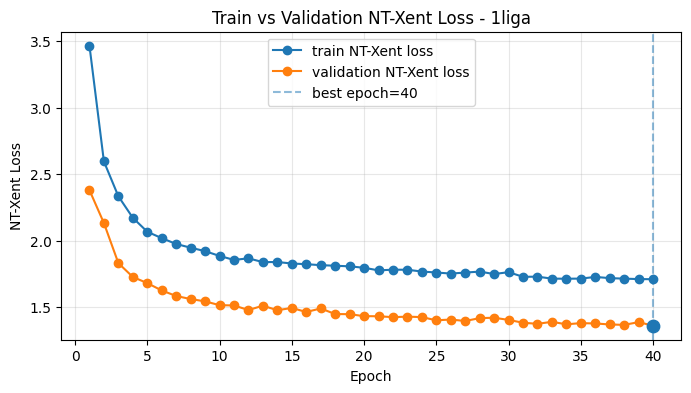

Interpretasi awal: Tidak ada indikasi kuat overfitting dari kurva train/validation loss. Tetap validasi dengan player retrieval, baseline raw grid, position consistency, dan heatmap.

Training dataset: 5liga
[5liga] n_total=41118 | n_train=32894 | n_val=8224
[5liga] Epoch 001/40 | train_loss=2.4493 | val_loss=1.6886 | best_epoch=1 | lr=0.000800
[5liga] Epoch 002/40 | train_loss=1.9455 | val_loss=1.5179 | best_epoch=2 | lr=0.000800
[5liga] Epoch 004/40 | train_loss=1.7972 | val_loss=1.4368 | best_epoch=4 | lr=0.000800
[5liga] Epoch 006/40 | train_loss=1.7514 | val_loss=1.4060 | best_epoch=6 | lr=0.000800
[5liga] Epoch 008/40 | train_loss=1.7289 | val_loss=1.3924 | best_epoch=7 | lr=0.000800
[5liga] Epoch 010/40 | train_loss=1.7091 | val_loss=1.3673 | best_epoch=10 | lr=0.000800
[5liga] Epoch 012/40 | train_loss=1.6979 | val_loss=1.3520 | best_epoch=12 | lr=0.000800
[5liga] Epoch 014/40 | train_loss=1.6912 | val_loss=1.3507 | best_epoch=14 | lr=0.000800
[5liga] Epoch 016/40 | train_loss=

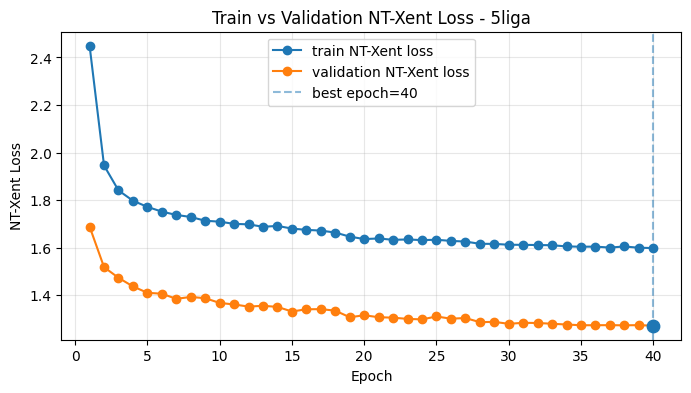

Interpretasi awal: Tidak ada indikasi kuat overfitting dari kurva train/validation loss. Tetap validasi dengan player retrieval, baseline raw grid, position consistency, dan heatmap.


In [12]:
from torch.utils.data import random_split, Subset


def make_train_val_loaders(X_array, dataset_name, val_ratio=VAL_RATIO):
    """Membuat DataLoader train dan validation untuk pretext task NT-Xent.

    Penting:
    - Train dataset memakai augmentasi stochastic.
    - Validation dataset memakai augmentasi deterministic per index.
      Ini mengurangi fluktuasi validation loss sehingga early stopping lebih stabil.
    """
    n_total = len(X_array)

    if n_total < 4:
        print(f"Warning: sample {dataset_name} terlalu sedikit untuk train/validation split. Semua data dipakai train.")
        train_indices = list(range(n_total))
        val_indices = []
    else:
        n_val = max(1, int(round(n_total * val_ratio)))
        n_train = n_total - n_val
        if n_train < 2:
            n_train = n_total - 1
            n_val = 1

        rng = np.random.default_rng(SEED)
        indices = np.arange(n_total)
        rng.shuffle(indices)
        val_indices = indices[:n_val].tolist()
        train_indices = indices[n_val:].tolist()

    train_ds_full = TouchGridContrastiveDataset(X_array, mode="train", seed=SEED)
    val_ds_full = TouchGridContrastiveDataset(X_array, mode="val", seed=SEED)

    train_ds = Subset(train_ds_full, train_indices)
    val_ds = Subset(val_ds_full, val_indices) if len(val_indices) > 0 else None

    # Untuk NT-Xent, batch berisi negatives. Jika batch terakhir hanya 1 sample,
    # loss tidak valid, jadi drop_last hanya jika datanya cukup.
    train_drop_last = len(train_ds) > BATCH_SIZE
    val_drop_last = False

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=train_drop_last,
    )

    val_loader = None
    if val_ds is not None:
        val_loader = DataLoader(
            val_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            drop_last=val_drop_last,
        )

    print(f"[{dataset_name}] n_total={n_total} | n_train={len(train_ds)} | n_val={0 if val_ds is None else len(val_ds)}")
    return train_loader, val_loader


def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []

    for v1, v2 in loader:
        if len(v1) < 2:
            continue

        v1 = v1.to(DEVICE)
        v2 = v2.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            z1 = model(v1)
            z2 = model(v2)
            loss = nt_xent_loss(z1, z2, TEMPERATURE)

            if torch.isnan(loss):
                continue

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        losses.append(float(loss.item()))

    return float(np.mean(losses)) if losses else np.nan


def train_ssl_model(X_array, dataset_name, epochs=EPOCHS):
    train_loader, val_loader = make_train_val_loaders(X_array, dataset_name)

    model = TouchMapEncoder(embed_dim=EMBED_DIM, dropout_rate=DROPOUT_RATE).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # Scheduler menurunkan LR jika validation loss plateau.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=max(1, PATIENCE // 2),
        min_lr=1e-5,
    )

    history = []
    best_state = None
    best_monitor = np.inf
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss = run_one_epoch(model, train_loader, optimizer=optimizer)

        if val_loader is not None:
            with torch.no_grad():
                val_loss = run_one_epoch(model, val_loader, optimizer=None)
        else:
            val_loss = np.nan

        monitor_loss = val_loss if not np.isnan(val_loss) else train_loss
        current_lr = optimizer.param_groups[0]["lr"]

        improved = monitor_loss < (best_monitor - MIN_DELTA)
        if improved:
            best_monitor = monitor_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if not np.isnan(monitor_loss):
            scheduler.step(monitor_loss)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "monitor_loss": monitor_loss,
            "best_monitor_loss": best_monitor,
            "learning_rate": current_lr,
            "is_best_epoch": improved,
        })

        if epoch == 1 or epoch % 2 == 0 or epoch == epochs:
            if np.isnan(val_loss):
                print(
                    f"[{dataset_name}] Epoch {epoch:03d}/{epochs} | "
                    f"train_loss={train_loss:.4f} | lr={current_lr:.6f}"
                )
            else:
                print(
                    f"[{dataset_name}] Epoch {epoch:03d}/{epochs} | "
                    f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
                    f"best_epoch={best_epoch} | lr={current_lr:.6f}"
                )

        if val_loader is not None and epochs_without_improvement >= PATIENCE:
            print(
                f"[{dataset_name}] Early stopping pada epoch {epoch}. "
                f"Best epoch: {best_epoch}, best val_loss: {best_monitor:.4f}"
            )
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"[{dataset_name}] Model dikembalikan ke best epoch {best_epoch}.")

    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / f"training_validation_history_{dataset_name}.csv", index=False)
    return model, history_df


def summarize_overfitting_signal(history_df):
    """Ringkasan sederhana untuk membantu pembahasan Bab IV.

    Ini bukan diagnosis final; sesuai literatur SSL, kualitas akhir tetap perlu
    dilihat dari player retrieval, perbandingan baseline raw grid, position consistency, dan visualisasi hasil.
    """
    if "val_loss" not in history_df.columns or history_df["val_loss"].isna().all():
        return "Validation loss tidak tersedia; cek player retrieval, perbandingan baseline, position consistency, dan heatmap."

    valid = history_df.dropna(subset=["val_loss"])
    if len(valid) == 0:
        return "Validation loss tidak tersedia; cek player retrieval, perbandingan baseline, position consistency, dan heatmap."

    best_row = valid.loc[valid["val_loss"].idxmin()]
    final_row = valid.iloc[-1]

    best_val = float(best_row["val_loss"])
    final_val = float(final_row["val_loss"])
    final_train = float(final_row["train_loss"])
    first_train = float(valid.iloc[0]["train_loss"])

    if final_val > best_val * 1.15 and final_train < first_train:
        return (
            "Ada indikasi generalization gap pada epoch akhir. "
            "Notebook memakai early stopping sehingga model akhir diambil dari best validation epoch, bukan epoch terakhir."
        )

    return (
        "Tidak ada indikasi kuat overfitting dari kurva train/validation loss. "
        "Tetap validasi dengan player retrieval, baseline raw grid, position consistency, dan heatmap."
    )


for dataset_name, art in dataset_artifacts.items():
    print(f"\nTraining dataset: {dataset_name}")
    model, history_df = train_ssl_model(art["X"], dataset_name)
    art["model"] = model
    art["history_df"] = history_df

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train NT-Xent loss")
    if "val_loss" in history_df.columns and not history_df["val_loss"].isna().all():
        plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation NT-Xent loss")

        best_valid = history_df.dropna(subset=["val_loss"])
        if len(best_valid) > 0:
            best_idx = best_valid["val_loss"].idxmin()
            best_epoch = history_df.loc[best_idx, "epoch"]
            best_val = history_df.loc[best_idx, "val_loss"]
            plt.axvline(best_epoch, linestyle="--", alpha=0.5, label=f"best epoch={int(best_epoch)}")
            plt.scatter([best_epoch], [best_val], s=80, zorder=5)

    plt.xlabel("Epoch")
    plt.ylabel("NT-Xent Loss")
    plt.title(f"Train vs Validation NT-Xent Loss - {dataset_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("Interpretasi awal:", summarize_overfitting_signal(history_df))

    torch.save(model.state_dict(), OUTPUT_DIR / f"touchmap_ssl_encoder_{dataset_name}_best.pt")


### 8A. Catatan Overfitting

Jika kurva sebelumnya menunjukkan `train_loss` terus turun tetapi `val_loss` fluktuatif atau naik, maka model tidak boleh diambil dari epoch terakhir. Notebook versi ini memperbaiki hal tersebut dengan:

- **early stopping** berdasarkan validation NT-Xent loss,
- **best checkpoint restoration**,
- **dropout** dan **weight decay**,
- **validation augmentation deterministic** agar kurva validation loss tidak terlalu berisik,
- **ReduceLROnPlateau scheduler** agar learning rate turun ketika validation loss plateau.

Interpretasi tetap mengikuti anjuran literatur SSL: loss pretext task bukan satu-satunya ukuran kualitas sistem. Model tetap harus dievaluasi melalui intra/inter similarity, top-k recommendation, dan heatmap comparison.


### 8B. Interpretasi Loss untuk Bab IV

Untuk pembahasan skripsi, jangan menyimpulkan kualitas model hanya dari loss training.

Formulasi pembahasan:

> Nilai NT-Xent loss yang menurun menunjukkan bahwa model berhasil mengoptimalkan objective contrastive learning. Namun, sesuai karakteristik self-supervised learning, loss pretext task tidak langsung merepresentasikan kualitas rekomendasi akhir. Oleh karena itu, evaluasi dilanjutkan dengan validation NT-Xent loss, intra-player vs inter-player similarity, hasil rekomendasi top-k, dan analisis heatmap.

Jika `train_loss` turun tetapi `val_loss` naik terus, tulis sebagai indikasi overfitting. Jika keduanya turun/stabil, tulis bahwa tidak ada indikasi kuat overfitting dari pretext objective, tetapi tetap perlu validasi embedding dan rekomendasi.


## 9. Membentuk Embedding Sample dan Embedding Pemain
Embedding sample player-match diagregasi dengan mean pooling menjadi embedding pemain.


In [13]:
def encode_samples(model, X_array, batch_size=256):
    model.eval()
    embeddings = []

    with torch.no_grad():
        for start in range(0, len(X_array), batch_size):
            batch = torch.tensor(X_array[start:start + batch_size]).unsqueeze(1).to(DEVICE)
            z = model(batch).detach().cpu().numpy()
            embeddings.append(z)

    return np.vstack(embeddings)


def build_sample_and_player_embeddings(meta, X_array, model, dataset_name):
    sample_emb = encode_samples(model, X_array)

    emb_cols = [f"emb_{i}" for i in range(sample_emb.shape[1])]
    sample_emb_df = meta.reset_index(drop=True).copy()

    for i, col in enumerate(emb_cols):
        sample_emb_df[col] = sample_emb[:, i]

    agg_dict = {col: "mean" for col in emb_cols}
    for c in ["dataset_name", "player_name", "role_name", "specific_position", "position_status", "team_name"]:
        if c in sample_emb_df.columns:
            agg_dict[c] = "first"

    agg_dict["match_id"] = "nunique"
    agg_dict["n_touches"] = "sum"

    player_emb = (
        sample_emb_df
        .groupby("player_id", as_index=False)
        .agg(agg_dict)
        .rename(columns={"match_id": "n_matches", "n_touches": "total_touches"})
    )

    mat = player_emb[emb_cols].to_numpy(dtype=float)
    mat = mat / (np.linalg.norm(mat, axis=1, keepdims=True) + 1e-8)
    player_emb[emb_cols] = mat

    sample_emb_df.to_csv(OUTPUT_DIR / f"sample_embeddings_{dataset_name}.csv", index=False)
    player_emb.to_csv(OUTPUT_DIR / f"player_embeddings_{dataset_name}.csv", index=False)

    return sample_emb_df, player_emb, emb_cols


for dataset_name, art in dataset_artifacts.items():
    sample_emb_df, player_emb, emb_cols = build_sample_and_player_embeddings(
        art["meta"], art["X"], art["model"], dataset_name
    )
    art["sample_emb_df"] = sample_emb_df
    art["player_emb_all"] = player_emb
    art["emb_cols"] = emb_cols

    print(f"\nDataset {dataset_name}")
    print("Sample embedding:", sample_emb_df.shape)
    print("Player embedding:", player_emb.shape)
    display(player_emb.head())



Dataset 1liga
Sample embedding: (8065, 78)
Player embedding: (306, 73)


,player_id,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_62,emb_63,dataset_name,player_name,role_name,specific_position,position_status,team_name,n_matches,total_touches
0,36,0.281704,0.067290,-0.015163,0.184138,-0.157797,0.005173,0.024019,-0.144887,-0.024487,...,-0.048292,0.111269,1liga,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,13,1132
1,48,0.234238,-0.076714,0.082824,0.041320,-0.045491,-0.117519,0.119518,-0.014096,-0.071310,...,-0.091473,0.191249,1liga,J. Vertonghen,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,36,3070
2,54,-0.161151,0.111270,-0.122990,0.294588,-0.026460,0.152034,0.088162,-0.155871,-0.046777,...,0.046771,-0.089945,1liga,C. Eriksen,Midfielder,CAM,MID_NEEDS_DETAIL,Tottenham Hotspur,37,3105
3,74,0.164035,-0.014491,0.074668,0.051619,-0.054144,-0.129179,0.154112,-0.008182,-0.099275,...,-0.023182,0.148155,1liga,R. Klavan,Defender,CB,DEF_NEEDS_DETAIL,Liverpool,16,1396
4,93,-0.129513,-0.090535,0.151272,0.025832,0.132998,0.148053,-0.089394,0.049553,0.160845,...,-0.002189,0.026321,1liga,J. Guðmundsson,Midfielder,RW,MID_NEEDS_DETAIL,Burnley,34,1616



Dataset 5liga
Sample embedding: (41118, 78)
Player embedding: (1698, 73)


,player_id,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_62,emb_63,dataset_name,player_name,role_name,specific_position,position_status,team_name,n_matches,total_touches
0,36,-0.161282,0.082850,-0.036406,-0.003502,-0.208490,-0.011523,0.041404,0.233505,0.237855,...,0.073982,0.020177,5liga,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,13,1132
1,48,-0.131030,-0.073210,-0.134459,-0.059799,-0.056546,-0.129365,-0.247503,-0.083796,-0.013670,...,0.054287,-0.003518,5liga,J. Vertonghen,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,36,3070
2,54,-0.123820,-0.201591,-0.043942,-0.102090,0.061366,-0.091993,-0.216342,0.105527,-0.173344,...,-0.016768,-0.160805,5liga,C. Eriksen,Midfielder,CAM,MID_NEEDS_DETAIL,Tottenham Hotspur,37,3105
3,74,-0.070497,-0.183630,-0.146415,-0.117764,-0.017612,-0.128604,-0.182268,-0.064750,-0.022946,...,-0.101010,-0.102589,5liga,R. Klavan,Defender,CB,DEF_NEEDS_DETAIL,Liverpool,16,1396
4,77,-0.110746,-0.010667,-0.055572,-0.110807,-0.055848,-0.113366,-0.268815,-0.094773,0.040259,...,0.060969,0.003892,5liga,N. Moisander,Defender,CB,DEF_NEEDS_DETAIL,Werder Bremen,25,1853


### 9A. Validasi Ulang Metadata Posisi Detail

Cell ini memastikan `player_emb_all` tetap memiliki `specific_position` dan `position_status` setelah agregasi embedding. Jika masih banyak `Unknown`, cell ini menampilkan diagnostik untuk cek apakah masalahnya dari ID/nama yang tidak cocok dengan Excel.


In [14]:
def reattach_position_to_player_embeddings(player_emb, position_lookup, verbose=True):
    """Re-merge metadata posisi ke level player embedding sebagai langkah pengaman."""
    out = merge_position_detail(player_emb, position_lookup, verbose=False)

    # Kalau hasil merge membuat kolom bantu tidak perlu di output akhir, tetap aman dibiarkan.
    if verbose:
        total = len(out)
        unknown = int((out["specific_position"] == "Unknown").sum()) if "specific_position" in out.columns else total
        pct = unknown / max(total, 1) * 100
        print(f"Unknown specific_position: {unknown}/{total} ({pct:.2f}%)")
        print("Distribusi specific_position:")
        display(out["specific_position"].value_counts(dropna=False).head(20))
        show_cols = [c for c in ["player_id", "player_name", "role_name", "specific_position", "position_status", "team_name", "n_matches", "total_touches"] if c in out.columns]
        display(out[show_cols].head(20))

    return out


for dataset_name, art in dataset_artifacts.items():
    print(f"\n=== Validasi posisi detail: {dataset_name} ===")
    art["player_emb_all"] = reattach_position_to_player_embeddings(art["player_emb_all"], position_lookup, verbose=True)

    # Simpan ulang hasil embedding dengan metadata posisi yang sudah diperbaiki
    art["player_emb_all"].to_csv(OUTPUT_DIR / f"player_embeddings_{dataset_name}_with_position_detail.csv", index=False)

# Buat variabel cepat untuk dataset utama kalau dibutuhkan di cell manual
MAIN_DATASET = "5liga" if "5liga" in dataset_artifacts else list(dataset_artifacts.keys())[0]
player_emb_all = dataset_artifacts[MAIN_DATASET]["player_emb_all"]
emb_cols = dataset_artifacts[MAIN_DATASET]["emb_cols"]
sample_level_df = dataset_artifacts[MAIN_DATASET]["meta"]
X = dataset_artifacts[MAIN_DATASET]["X"]
print("\nDataset utama:", MAIN_DATASET)



=== Validasi posisi detail: 1liga ===
Unknown specific_position: 0/306 (0.00%)
Distribusi specific_position:


specific_position
CB     67
CM     44
ST     44
LB     30
RB     29
RW     27
LW     27
CDM    21
CAM    17
Name: count, dtype: int64

,player_id,player_name,role_name,specific_position,position_status,team_name,n_matches,total_touches
0,36,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,13,1132
1,48,J. Vertonghen,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,36,3070
2,54,C. Eriksen,Midfielder,CAM,MID_NEEDS_DETAIL,Tottenham Hotspur,37,3105
3,74,R. Klavan,Defender,CB,DEF_NEEDS_DETAIL,Liverpool,16,1396
4,93,J. Guðmundsson,Midfielder,RW,MID_NEEDS_DETAIL,Burnley,34,1616
5,107,E. Pieters,Defender,LB,DEF_NEEDS_DETAIL,Stoke City,31,1719
6,116,G. Wijnaldum,Midfielder,CM,MID_NEEDS_DETAIL,Liverpool,30,1652
7,132,T. Kongolo,Defender,LB,DEF_NEEDS_DETAIL,Huddersfield Town,13,553
8,134,B. Martins Indi,Defender,CB,DEF_NEEDS_DETAIL,Stoke City,16,521
9,160,D. Janmaat,Defender,RB,DEF_NEEDS_DETAIL,Watford,23,1285



=== Validasi posisi detail: 5liga ===
Unknown specific_position: 0/1698 (0.00%)
Distribusi specific_position:


specific_position
CB     348
ST     266
CM     256
RB     157
CDM    157
RW     151
LB     148
LW     146
CAM     69
Name: count, dtype: int64

,player_id,player_name,role_name,specific_position,position_status,team_name,n_matches,total_touches
0,36,T. Alderweireld,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,13,1132
1,48,J. Vertonghen,Defender,CB,DEF_NEEDS_DETAIL,Tottenham Hotspur,36,3070
2,54,C. Eriksen,Midfielder,CAM,MID_NEEDS_DETAIL,Tottenham Hotspur,37,3105
3,74,R. Klavan,Defender,CB,DEF_NEEDS_DETAIL,Liverpool,16,1396
4,77,N. Moisander,Defender,CB,DEF_NEEDS_DETAIL,Werder Bremen,25,1853
5,93,J. Guðmundsson,Midfielder,RW,MID_NEEDS_DETAIL,Burnley,34,1616
6,102,Marcelo,Defender,CB,DEF_NEEDS_DETAIL,Olympique Lyonnais,35,2682
7,107,E. Pieters,Defender,LB,DEF_NEEDS_DETAIL,Stoke City,31,1719
8,110,J. Willems,Defender,LB,DEF_NEEDS_DETAIL,Eintracht Frankfurt,22,1223
9,114,K. Strootman,Midfielder,CM,MID_NEEDS_DETAIL,Roma,31,1782



Dataset utama: 5liga


## 10. Pembentukan Baseline Tanpa SSL: Raw Touch Map Grid

Bagian ini membentuk baseline tanpa proses pembelajaran representasi. Setiap `spatial grid` pada tingkat *player-match* diratakan menjadi vektor, kemudian sistem mengagregasi vektor tersebut pada tingkat pemain. Baseline dan metode SSL sama-sama menggunakan *cosine similarity*, sehingga perbedaan hasil evaluasi berfokus pada penggunaan representasi hasil SSL.

Baseline ini tidak menggantikan metode utama. Baseline digunakan untuk menjawab apakah *embedding* hasil SSL memberikan manfaat dibandingkan representasi spasial awal yang langsung digunakan untuk pencarian kemiripan.


In [15]:

def l2_normalize_rows(matrix, eps=1e-8):
    """Normalisasi L2 per baris untuk perhitungan cosine similarity."""
    matrix = np.asarray(matrix, dtype=np.float32)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / (norms + eps)


def aggregate_player_representation(sample_df, feature_cols):
    """Mengagregasi representasi level player-match menjadi level pemain."""
    agg_dict = {col: "mean" for col in feature_cols}
    for col in ["dataset_name", "player_name", "role_name", "specific_position", "position_status", "team_name"]:
        if col in sample_df.columns:
            agg_dict[col] = "first"
    if "match_id" in sample_df.columns:
        agg_dict["match_id"] = "nunique"
    if "n_touches" in sample_df.columns:
        agg_dict["n_touches"] = "sum"

    player_df = (
        sample_df
        .groupby("player_id", as_index=False)
        .agg(agg_dict)
        .rename(columns={"match_id": "n_matches", "n_touches": "total_touches"})
    )
    return player_df


def build_raw_grid_representation(meta, X_array, dataset_name):
    """Membentuk representasi baseline dari grid tanpa SSL."""
    if len(meta) != len(X_array):
        raise ValueError(f"{dataset_name}: panjang metadata dan jumlah grid tidak sama.")

    flat_grid = np.asarray(X_array, dtype=np.float32).reshape(len(X_array), -1)
    raw_cols = [f"raw_grid_{i}" for i in range(flat_grid.shape[1])]

    sample_raw_df = meta.reset_index(drop=True).copy()
    sample_raw_df[raw_cols] = flat_grid

    player_raw_df = aggregate_player_representation(sample_raw_df, raw_cols)
    player_raw_df = reattach_position_to_player_embeddings(player_raw_df, position_lookup, verbose=False)

    sample_raw_df.to_csv(OUTPUT_DIR / f"sample_raw_grid_{dataset_name}.csv", index=False)
    player_raw_df.to_csv(OUTPUT_DIR / f"player_raw_grid_{dataset_name}.csv", index=False)

    return sample_raw_df, player_raw_df, raw_cols


for dataset_name, art in dataset_artifacts.items():
    sample_raw_df, player_raw_df, raw_cols = build_raw_grid_representation(
        art["meta"], art["X"], dataset_name
    )
    art["sample_raw_df"] = sample_raw_df
    art["player_raw_all"] = player_raw_df
    art["raw_cols"] = raw_cols

    print(f"\nBaseline raw grid selesai dibuat: {dataset_name}")
    print("Player-match raw representation:", sample_raw_df.shape)
    print("Player-level raw representation:", player_raw_df.shape)
    display(player_raw_df[[c for c in [
        "player_id", "player_name", "role_name", "specific_position",
        "n_matches", "total_touches"
    ] if c in player_raw_df.columns]].head())



Baseline raw grid selesai dibuat: 1liga
Player-match raw representation: (8065, 206)
Player-level raw representation: (306, 205)


,player_id,player_name,role_name,specific_position,n_matches,total_touches
0,36,T. Alderweireld,Defender,CB,13,1132
1,48,J. Vertonghen,Defender,CB,36,3070
2,54,C. Eriksen,Midfielder,CAM,37,3105
3,74,R. Klavan,Defender,CB,16,1396
4,93,J. Guðmundsson,Midfielder,RW,34,1616



Baseline raw grid selesai dibuat: 5liga
Player-match raw representation: (41118, 206)
Player-level raw representation: (1698, 205)


,player_id,player_name,role_name,specific_position,n_matches,total_touches
0,36,T. Alderweireld,Defender,CB,13,1132
1,48,J. Vertonghen,Defender,CB,36,3070
2,54,C. Eriksen,Midfielder,CAM,37,3105
3,74,R. Klavan,Defender,CB,16,1396
4,77,N. Moisander,Defender,CB,25,1853


## 11. Evaluasi Representasi: Intra-Player dan Inter-Player Similarity

Evaluasi representasi membandingkan kemiripan antarsampel pertandingan milik pemain yang sama (*intra-player similarity*) dengan kemiripan antarsampel milik pemain berbeda (*inter-player similarity*). Representasi yang lebih baik diharapkan memiliki nilai *intra-player similarity* yang lebih tinggi daripada *inter-player similarity*, sehingga menghasilkan nilai selisih atau *gap* yang lebih besar.

Evaluasi dijalankan pada dua skenario, yaitu `raw_grid_baseline` dan `ssl_embedding`. Dengan rancangan ini, penelitian dapat menilai apakah proses pembelajaran representasi melalui SSL membentuk ruang representasi yang lebih terstruktur dibandingkan penggunaan distribusi spasial awal secara langsung. Interval kepercayaan bootstrap disediakan untuk membantu membaca kestabilan perbedaan nilai *gap*.


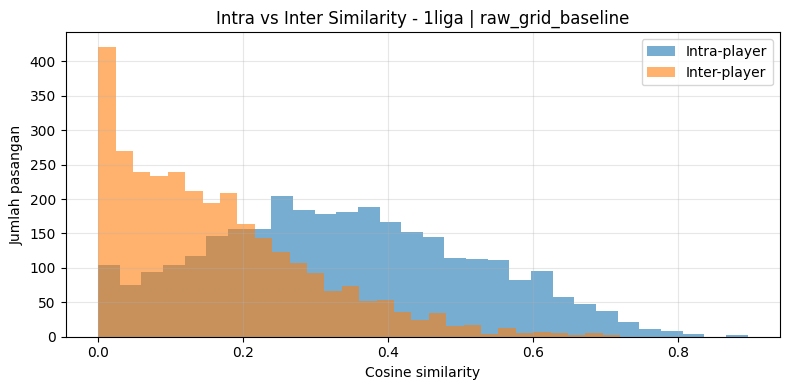

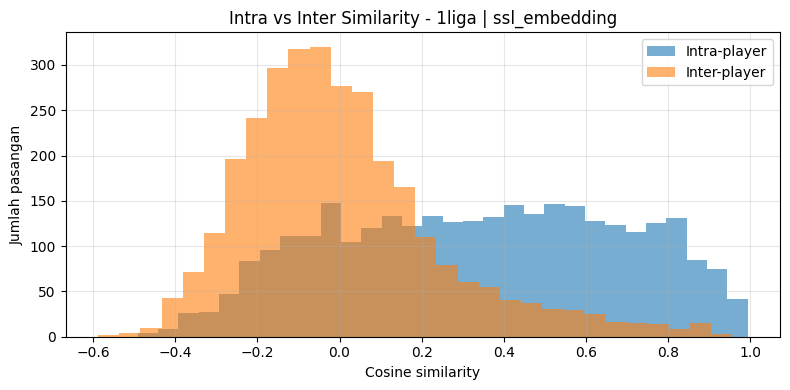

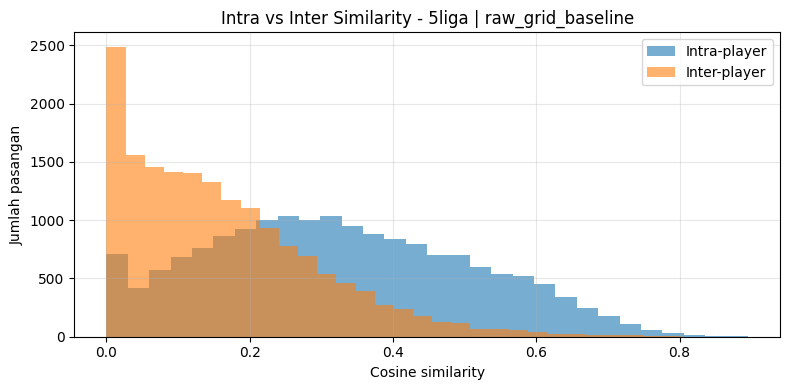

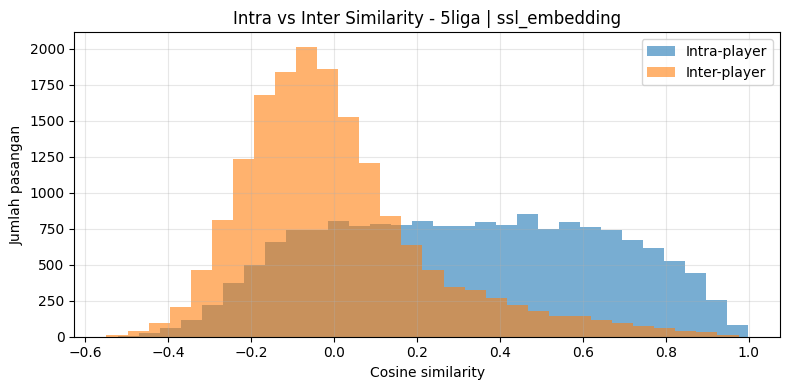

Evaluasi Representasi: Raw Grid vs SSL Embedding


,dataset,representation,mean_intra_similarity,mean_inter_similarity,gap_intra_minus_inter,gap_ci_95_low,gap_ci_95_high,n_intra_pairs,n_inter_pairs
0,1liga,raw_grid_baseline,0.337923,0.161486,0.176437,0.168944,0.183896,3060,3060
1,1liga,ssl_embedding,0.336984,0.003035,0.333949,0.318224,0.348678,3060,3060
2,5liga,raw_grid_baseline,0.325697,0.162224,0.163473,0.160130,0.166884,16980,16980
3,5liga,ssl_embedding,0.310800,0.002991,0.307809,0.301371,0.313990,16980,16980


Peningkatan Gap Representasi oleh SSL


representation,dataset,raw_grid_baseline,ssl_embedding,improvement_ssl_minus_raw
0,1liga,0.176437,0.333949,0.157513
1,5liga,0.163473,0.307809,0.144336


In [16]:
# EVALUASI REPRESENTASI: INTRA-PLAYER vs INTER-PLAYER SIMILARITY
# RAW GRID BASELINE vs SSL EMBEDDING

def bootstrap_gap_ci(intra_values, inter_values, n_bootstrap=1000, random_state=SEED):
    """
    Menghitung 95% bootstrap confidence interval untuk gap:
    mean(intra-player similarity) - mean(inter-player similarity).
    """
    rng = np.random.default_rng(random_state)
    intra_values = np.asarray(intra_values, dtype=float)
    inter_values = np.asarray(inter_values, dtype=float)

    if len(intra_values) == 0 or len(inter_values) == 0:
        return np.nan, np.nan

    boot_gaps = np.empty(n_bootstrap, dtype=float)
    for b in range(n_bootstrap):
        intra_sample = rng.choice(intra_values, size=len(intra_values), replace=True)
        inter_sample = rng.choice(inter_values, size=len(inter_values), replace=True)
        boot_gaps[b] = intra_sample.mean() - inter_sample.mean()

    ci_low, ci_high = np.percentile(boot_gaps, [2.5, 97.5])
    return float(ci_low), float(ci_high)


def sample_intra_inter_similarity(
    sample_df,
    feature_cols,
    dataset_name,
    representation_name,
    max_pairs=20000,
    random_state=SEED,
):
    """
    Mengukur struktur representasi pada level player-match.

    Intra-player:
        Pasangan sampel pertandingan milik pemain yang sama.
    Inter-player:
        Pasangan sampel pertandingan milik pemain berbeda.

    Catatan:
        Evaluasi ini menilai struktur representasi, bukan akurasi
        kesamaan gaya bermain secara menyeluruh.
    """
    rng = np.random.default_rng(random_state)
    df = sample_df.reset_index(drop=True).copy()
    vectors = l2_normalize_rows(df[feature_cols].to_numpy(dtype=np.float32))
    player_ids = df["player_id"].to_numpy()

    intra_pairs = []
    for _, indices in df.groupby("player_id").groups.items():
        indices = np.array(list(indices), dtype=int)
        if len(indices) < 2:
            continue

        max_group_pairs = len(indices) * (len(indices) - 1) // 2
        draws = min(10, max_group_pairs)
        selected = set()

        while len(selected) < draws:
            i, j = rng.choice(indices, size=2, replace=False)
            selected.add(tuple(sorted((int(i), int(j)))))

        intra_pairs.extend(list(selected))
        if len(intra_pairs) >= max_pairs:
            intra_pairs = intra_pairs[:max_pairs]
            break

    intra_values = np.array(
        [float(vectors[i] @ vectors[j]) for i, j in intra_pairs],
        dtype=float
    )

    target_inter = len(intra_values)
    inter_values = []
    attempts = 0
    max_attempts = max(target_inter * 50, 1000)

    while len(inter_values) < target_inter and attempts < max_attempts:
        i, j = rng.integers(0, len(df), size=2)
        if i != j and player_ids[i] != player_ids[j]:
            inter_values.append(float(vectors[i] @ vectors[j]))
        attempts += 1

    inter_values = np.array(inter_values, dtype=float)

    mean_intra = float(np.mean(intra_values)) if len(intra_values) else np.nan
    mean_inter = float(np.mean(inter_values)) if len(inter_values) else np.nan
    gap = mean_intra - mean_inter if len(intra_values) and len(inter_values) else np.nan
    ci_low, ci_high = bootstrap_gap_ci(
        intra_values, inter_values, n_bootstrap=1000, random_state=random_state
    )

    summary = {
        "dataset": dataset_name,
        "representation": representation_name,
        "mean_intra_similarity": mean_intra,
        "mean_inter_similarity": mean_inter,
        "gap_intra_minus_inter": gap,
        "gap_ci_95_low": ci_low,
        "gap_ci_95_high": ci_high,
        "n_intra_pairs": len(intra_values),
        "n_inter_pairs": len(inter_values),
    }
    return summary, intra_values, inter_values


intra_inter_rows = []
intra_inter_distributions = {}

for dataset_name, art in dataset_artifacts.items():
    for representation_name, sample_df, feature_cols in [
        ("raw_grid_baseline", art["sample_raw_df"], art["raw_cols"]),
        ("ssl_embedding", art["sample_emb_df"], art["emb_cols"]),
    ]:
        summary, intra_values, inter_values = sample_intra_inter_similarity(
            sample_df=sample_df,
            feature_cols=feature_cols,
            dataset_name=dataset_name,
            representation_name=representation_name,
        )
        intra_inter_rows.append(summary)
        intra_inter_distributions[(dataset_name, representation_name)] = {
            "intra": intra_values,
            "inter": inter_values,
        }

        plt.figure(figsize=(8, 4))
        plt.hist(intra_values, bins=30, alpha=0.6, label="Intra-player")
        plt.hist(inter_values, bins=30, alpha=0.6, label="Inter-player")
        plt.xlabel("Cosine similarity")
        plt.ylabel("Jumlah pasangan")
        plt.title(f"Intra vs Inter Similarity - {dataset_name} | {representation_name}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

intra_inter_comparison_df = pd.DataFrame(intra_inter_rows).sort_values(
    ["dataset", "representation"]
).reset_index(drop=True)

print("Evaluasi Representasi: Raw Grid vs SSL Embedding")
display(intra_inter_comparison_df)
intra_inter_comparison_df.to_csv(
    OUTPUT_DIR / "intra_inter_similarity_raw_vs_ssl.csv",
    index=False
)

# Ringkasan peningkatan gap SSL terhadap baseline.
gap_pivot = intra_inter_comparison_df.pivot(
    index="dataset",
    columns="representation",
    values="gap_intra_minus_inter"
).reset_index()

if {"raw_grid_baseline", "ssl_embedding"}.issubset(gap_pivot.columns):
    gap_pivot["improvement_ssl_minus_raw"] = (
        gap_pivot["ssl_embedding"] - gap_pivot["raw_grid_baseline"]
    )
    print("Peningkatan Gap Representasi oleh SSL")
    display(gap_pivot)
    gap_pivot.to_csv(OUTPUT_DIR / "gap_improvement_ssl_vs_raw.csv", index=False)


## 12. Rekomendasi Top-k Pemain pada Baseline dan Metode SSL

Bagian ini menghasilkan rekomendasi pemain pada dua skenario representasi. Baseline menghitung kemiripan langsung dari vektor *raw grid*, sedangkan metode utama menghitung kemiripan dari *embedding* hasil SSL. Kedua skenario menggunakan *cosine similarity* dan jumlah rekomendasi yang sama.

Hasil rekomendasi SSL digunakan sebagai keluaran utama aplikasi. Hasil rekomendasi baseline digunakan sebagai pembanding untuk mendukung analisis kontribusi metode SSL.


In [17]:

def find_player_matches(query, player_df, name_col="player_name", max_results=20):
    query_key = make_name_key(query)
    df = player_df.copy()
    df["_name_key"] = df[name_col].apply(make_name_key)
    matches = df[df["_name_key"].str.contains(query_key, na=False)]

    show_cols = [
        "player_id", "player_name", "role_name", "specific_position",
        "position_status", "team_name", "n_matches", "total_touches"
    ]
    show_cols = [c for c in show_cols if c in matches.columns]
    display(matches[show_cols].head(max_results))
    return matches[show_cols].head(max_results)


def recommend_by_representation(
    player_name,
    player_df,
    feature_cols,
    representation_name,
    top_k=TOP_K,
    name_col="player_name",
    verbose=True,
):
    df = player_df.copy().reset_index(drop=True)
    df["_name_key"] = df[name_col].apply(make_name_key)
    query_key = make_name_key(player_name)

    exact = df[df["_name_key"] == query_key]
    if len(exact) == 0:
        partial = df[df["_name_key"].str.contains(query_key, na=False)]
        if verbose:
            print(f"Tidak ada exact match untuk '{player_name}'.")
            if len(partial) > 0:
                print("Partial match ditemukan:")
                display(partial[[c for c in [
                    "player_id", "player_name", "role_name", "specific_position", "team_name"
                ] if c in partial.columns]].head(20))
        return None, None

    target_idx = exact.index[0]
    vectors = l2_normalize_rows(df[feature_cols].to_numpy(dtype=np.float32))
    similarities = vectors @ vectors[target_idx]
    similarities[target_idx] = -np.inf

    df["similarity_score"] = similarities
    df["representation"] = representation_name
    recs = df.sort_values("similarity_score", ascending=False).head(top_k).copy()

    target_cols = [c for c in [
        "player_id", "player_name", "role_name", "specific_position",
        "team_name", "n_matches", "total_touches"
    ] if c in df.columns]
    result_cols = target_cols + ["representation", "similarity_score"]

    if verbose:
        print(f"Target Player | representation={representation_name}")
        display(df.loc[[target_idx], target_cols])
        print(f"Top {top_k} Recommendations")
        display(recs[result_cols])

    return df.loc[[target_idx], target_cols], recs[result_cols]


MAIN_DATASET = "5liga" if "5liga" in dataset_artifacts else list(dataset_artifacts.keys())[0]
TARGET_PLAYER_NAME = "M. Özil"

main_art = dataset_artifacts[MAIN_DATASET]

target_raw_df, recommendations_raw_df = recommend_by_representation(
    player_name=TARGET_PLAYER_NAME,
    player_df=main_art["player_raw_all"],
    feature_cols=main_art["raw_cols"],
    representation_name="raw_grid_baseline",
    top_k=TOP_K,
    verbose=True,
)

target_ssl_df, recommendations_ssl_df = recommend_by_representation(
    player_name=TARGET_PLAYER_NAME,
    player_df=main_art["player_emb_all"],
    feature_cols=main_art["emb_cols"],
    representation_name="ssl_embedding",
    top_k=TOP_K,
    verbose=True,
)

if recommendations_raw_df is not None:
    recommendations_raw_df.to_csv(
        OUTPUT_DIR / f"recommendation_raw_grid_{MAIN_DATASET}_{make_name_key(TARGET_PLAYER_NAME).replace(' ', '_')}.csv",
        index=False
    )
if recommendations_ssl_df is not None:
    recommendations_ssl_df.to_csv(
        OUTPUT_DIR / f"recommendation_ssl_{MAIN_DATASET}_{make_name_key(TARGET_PLAYER_NAME).replace(' ', '_')}.csv",
        index=False
    )


Target Player | representation=raw_grid_baseline


,player_id,player_name,role_name,specific_position,team_name,n_matches,total_touches
63,3319,M. Özil,Midfielder,CAM,Arsenal,26,2372


Top 10 Recommendations


,player_id,player_name,role_name,specific_position,team_name,n_matches,total_touches,representation,similarity_score
2,54,C. Eriksen,Midfielder,CAM,Tottenham Hotspur,37,3105,raw_grid_baseline,0.926371
993,38021,K. De Bruyne,Midfielder,CAM,Manchester City,37,3634,raw_grid_baseline,0.913293
837,25707,E. Hazard,Forward,LW,Chelsea,34,2326,raw_grid_baseline,0.904063
678,20879,R. Nainggolan,Midfielder,CM,Roma,31,1893,raw_grid_baseline,0.901503
462,14806,M. Götze,Midfielder,CM,Borussia Dortmund,22,1329,raw_grid_baseline,0.899896
922,26384,G. Kakuta,Midfielder,ST,Amiens SC,36,2320,raw_grid_baseline,0.899166
900,26100,N. Sliti,Midfielder,LW,Dijon,31,1666,raw_grid_baseline,0.899085
336,8317,David Silva,Midfielder,CAM,Manchester City,29,3034,raw_grid_baseline,0.894289
979,32652,E. Çolak,Midfielder,CAM,Deportivo La Coruña,26,1156,raw_grid_baseline,0.890369
509,15051,L. Stindl,Forward,ST,Borussia M'gladbach,31,2242,raw_grid_baseline,0.888101


Target Player | representation=ssl_embedding


,player_id,player_name,role_name,specific_position,team_name,n_matches,total_touches
63,3319,M. Özil,Midfielder,CAM,Arsenal,26,2372


Top 10 Recommendations


,player_id,player_name,role_name,specific_position,team_name,n_matches,total_touches,representation,similarity_score
336,8317,David Silva,Midfielder,CAM,Manchester City,29,3034,ssl_embedding,0.877008
564,16025,M. Kruse,Forward,ST,Werder Bremen,28,1802,ssl_embedding,0.861250
2,54,C. Eriksen,Midfielder,CAM,Tottenham Hotspur,37,3105,ssl_embedding,0.849622
848,25776,W. Khazri,Midfielder,ST,Rennes,24,1233,ssl_embedding,0.844515
79,3344,Rafinha,Midfielder,CM,Internazionale,16,1041,ssl_embedding,0.842081
1090,70096,J. Rodríguez,Midfielder,CAM,Bayern München,23,1906,ssl_embedding,0.837660
949,28122,Y. Benzia,Forward,CAM,Lille,31,1918,ssl_embedding,0.833042
514,15107,Raffael,Forward,ST,Borussia M'gladbach,27,1280,ssl_embedding,0.831489
993,38021,K. De Bruyne,Midfielder,CAM,Manchester City,37,3634,ssl_embedding,0.823589
462,14806,M. Götze,Midfielder,CM,Borussia Dortmund,22,1329,ssl_embedding,0.807416


## 13. Evaluasi Proksi Rekomendasi: Position Consistency@5

Evaluasi proksi rekomendasi mengukur proporsi kandidat pada lima rekomendasi teratas yang memiliki kategori peran atau posisi spesifik yang sama dengan pemain acuan. Evaluasi ini digunakan untuk memeriksa kewajaran hasil rekomendasi dalam konteks *scouting*, bukan sebagai *ground truth* atau ukuran akurasi kemiripan gaya bermain secara menyeluruh.

Evaluasi dilakukan pada tiga skenario, yaitu `random_baseline`, `raw_grid_baseline`, dan `ssl_embedding`. Perbandingan dengan *raw grid* menilai kontribusi SSL, sedangkan perbandingan dengan *random baseline* menunjukkan apakah rekomendasi sistem memiliki kewajaran posisi yang lebih baik daripada pemilihan kandidat secara acak.


Evaluasi Pendukung: Position Consistency@5


,dataset,representation,category,consistency_at_5
0,1liga,random_baseline,role_name,0.359255
1,1liga,raw_grid_baseline,role_name,0.883007
2,1liga,ssl_embedding,role_name,0.881046
3,1liga,random_baseline,specific_position,0.129386
4,1liga,raw_grid_baseline,specific_position,0.708497
5,1liga,ssl_embedding,specific_position,0.750980
6,5liga,random_baseline,role_name,0.351353
7,5liga,raw_grid_baseline,role_name,0.860542
8,5liga,ssl_embedding,role_name,0.857479
9,5liga,random_baseline,specific_position,0.130588


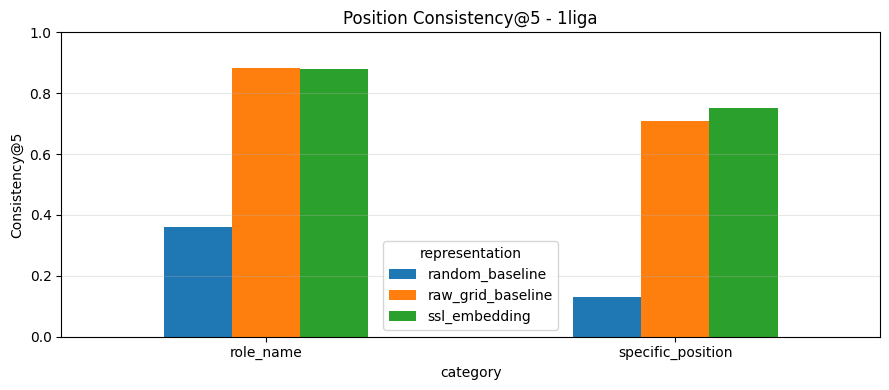

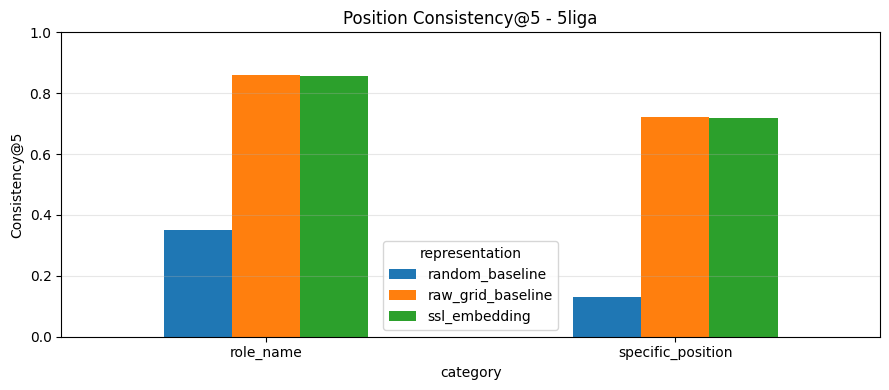

In [18]:

def topk_category_consistency(player_df, feature_cols, category_col, k=5):
    if category_col not in player_df.columns:
        return np.nan, pd.DataFrame()

    df = player_df.copy().reset_index(drop=True)
    df[category_col] = df[category_col].fillna("Unknown").astype(str)
    valid_df = df[~df[category_col].isin(["Unknown", "", "nan", "None"])].reset_index(drop=True)

    if len(valid_df) < k + 1:
        return np.nan, pd.DataFrame()

    vectors = l2_normalize_rows(valid_df[feature_cols].to_numpy(dtype=np.float32))
    sim = vectors @ vectors.T
    np.fill_diagonal(sim, -np.inf)

    rows = []
    scores = []
    for i in range(len(valid_df)):
        top_idx = np.argsort(-sim[i])[:k]
        target_label = valid_df.loc[i, category_col]
        neighbor_labels = valid_df.loc[top_idx, category_col].astype(str).tolist()
        same_ratio = float(np.mean([label == target_label for label in neighbor_labels]))
        scores.append(same_ratio)
        rows.append({
            "player_id": valid_df.loc[i, "player_id"],
            "player_name": valid_df.loc[i, "player_name"],
            category_col: target_label,
            f"{category_col}_consistency_at{k}": same_ratio,
            "topk_neighbors": ", ".join(valid_df.loc[top_idx, "player_name"].astype(str).tolist()),
            "topk_neighbor_categories": ", ".join(neighbor_labels),
        })

    return float(np.mean(scores)), pd.DataFrame(rows)


def random_category_consistency(player_df, category_col, k=5, repeats=200, random_state=SEED):
    """Pembanding acak: kandidat dipilih secara acak tanpa menggunakan representasi."""
    rng = np.random.default_rng(random_state)
    df = player_df.copy().reset_index(drop=True)
    df[category_col] = df[category_col].fillna("Unknown").astype(str)
    valid_df = df[~df[category_col].isin(["Unknown", "", "nan", "None"])].reset_index(drop=True)

    if len(valid_df) < k + 1:
        return np.nan

    labels = valid_df[category_col].to_numpy()
    repeat_scores = []
    all_idx = np.arange(len(valid_df))

    for _ in range(repeats):
        scores = []
        for i in all_idx:
            candidates = all_idx[all_idx != i]
            chosen = rng.choice(candidates, size=k, replace=False)
            scores.append(np.mean(labels[chosen] == labels[i]))
        repeat_scores.append(np.mean(scores))

    return float(np.mean(repeat_scores))


position_rows = []

for dataset_name, art in dataset_artifacts.items():
    for category_col in ["role_name", "specific_position"]:
        random_score = random_category_consistency(
            art["player_emb_all"], category_col=category_col, k=5
        )
        position_rows.append({
            "dataset": dataset_name,
            "representation": "random_baseline",
            "category": category_col,
            "consistency_at_5": random_score,
        })

        for representation_name, player_df, feature_cols in [
            ("raw_grid_baseline", art["player_raw_all"], art["raw_cols"]),
            ("ssl_embedding", art["player_emb_all"], art["emb_cols"]),
        ]:
            score, detail_df = topk_category_consistency(
                player_df=player_df,
                feature_cols=feature_cols,
                category_col=category_col,
                k=5,
            )
            position_rows.append({
                "dataset": dataset_name,
                "representation": representation_name,
                "category": category_col,
                "consistency_at_5": score,
            })

            detail_df.to_csv(
                OUTPUT_DIR / f"position_consistency_detail_{dataset_name}_{representation_name}_{category_col}_at5.csv",
                index=False
            )

position_consistency_comparison_df = pd.DataFrame(position_rows).sort_values(
    ["dataset", "category", "representation"]
).reset_index(drop=True)

print("Evaluasi Pendukung: Position Consistency@5")
display(position_consistency_comparison_df)
position_consistency_comparison_df.to_csv(
    OUTPUT_DIR / "position_consistency_raw_vs_ssl_vs_random.csv",
    index=False
)

for dataset_name in position_consistency_comparison_df["dataset"].unique():
    tmp = position_consistency_comparison_df[
        position_consistency_comparison_df["dataset"] == dataset_name
    ].pivot(index="category", columns="representation", values="consistency_at_5")
    ax = tmp.plot(kind="bar", figsize=(9, 4), rot=0)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Consistency@5")
    ax.set_title(f"Position Consistency@5 - {dataset_name}")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## 14. Visualisasi Heatmap untuk Interpretasi Hasil Rekomendasi SSL

Visualisasi heatmap digunakan untuk menjelaskan pola aktivitas pemain acuan dan kandidat utama dari metode SSL. Visualisasi ini membantu pengguna membaca area lapangan yang dominan pada rekomendasi, tetapi tidak menjadi ukuran utama keberhasilan model.

Aplikasi Streamlit tetap menggunakan hasil rekomendasi dari `ssl_embedding` sebagai metode utama. Baseline raw grid hanya digunakan dalam tahap evaluasi penelitian.


Saved: /Users/el/Downloads/streamlit_player_recommender/Football-Player-Scouting-Recommendation-System/outputs_ssl_vs_rawgrid_position_proxy/heatmap_comparison_5liga_m_ozil_top5.png


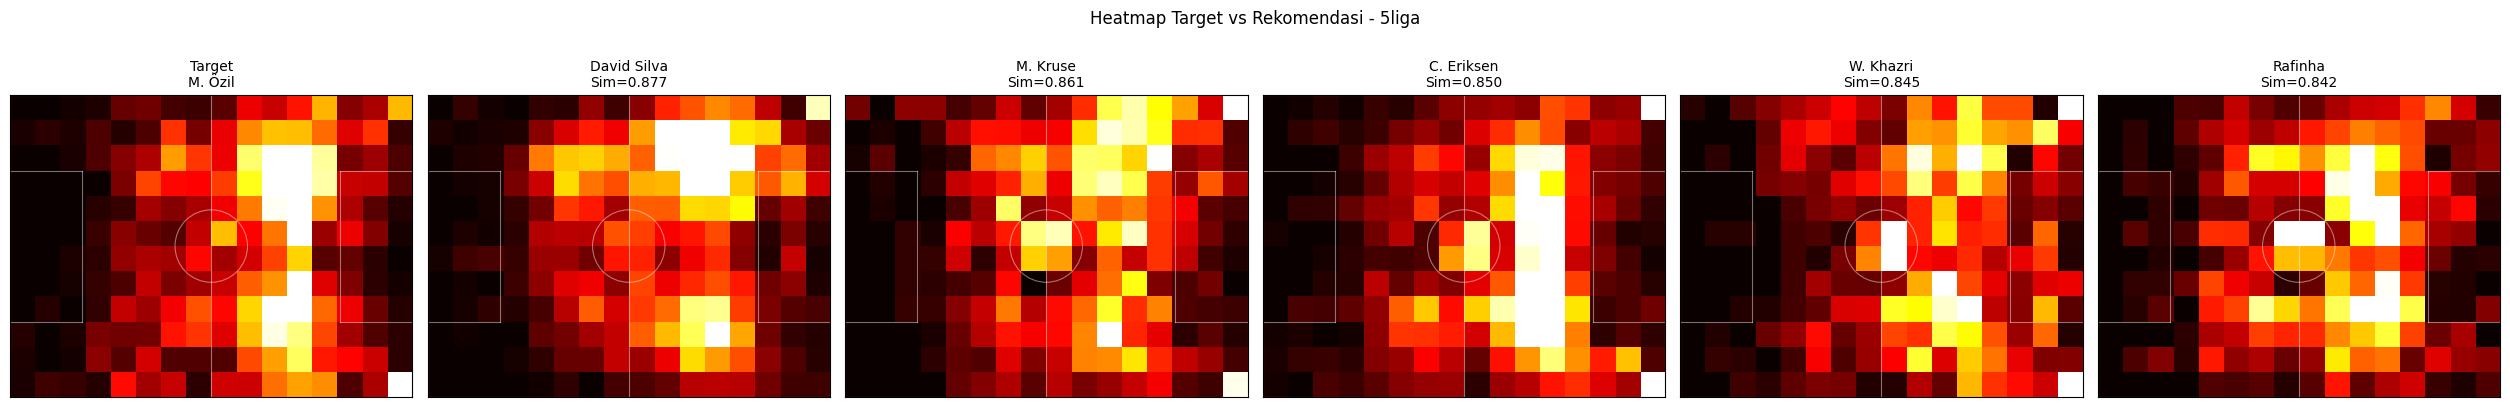

Saved: /Users/el/Downloads/streamlit_player_recommender/Football-Player-Scouting-Recommendation-System/outputs_ssl_vs_rawgrid_position_proxy/heatmap_difference_5liga_m_ozil_top5.png


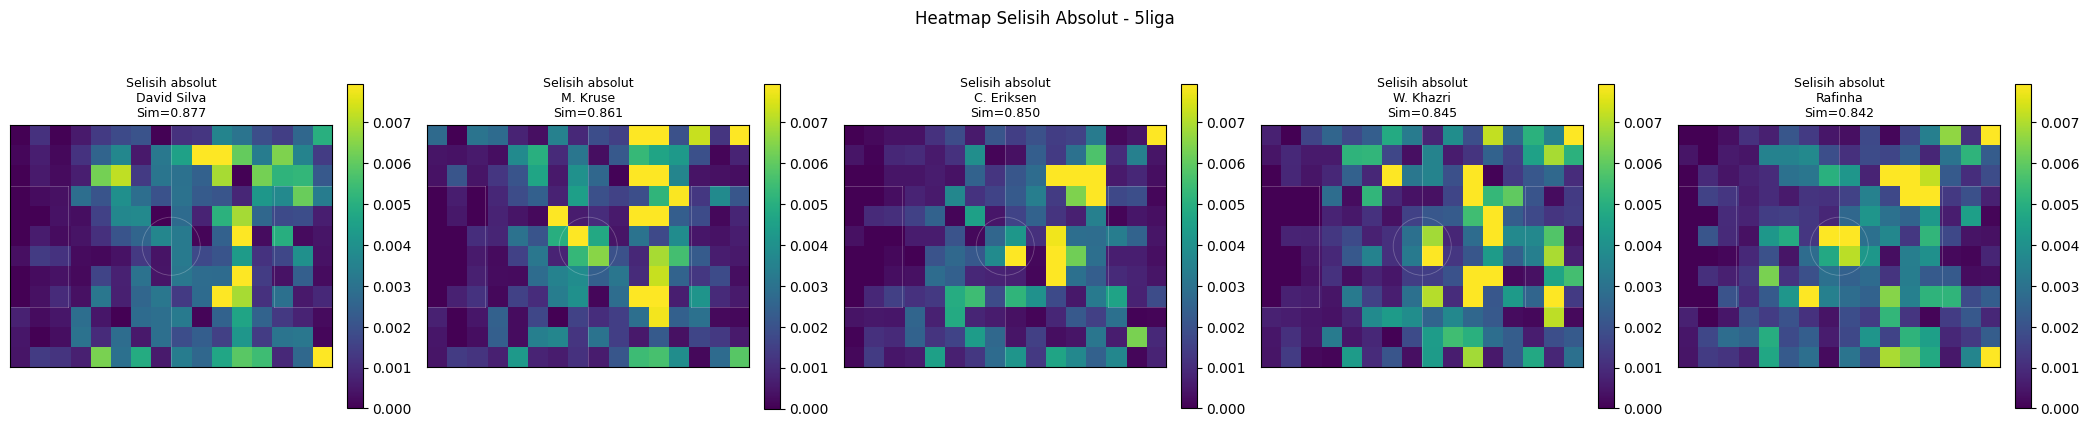

In [19]:
def get_player_mean_grid(player_name=None, player_id=None, sample_df=None, X_array=None):
    df = sample_df.copy().reset_index(drop=True)

    if player_id is not None:
        idx = df.index[df["player_id"].astype(str) == str(player_id)].tolist()
        label = str(player_id)
    elif player_name is not None:
        query_key = make_name_key(player_name)
        keys = df["player_name"].apply(make_name_key)
        idx = df.index[keys == query_key].tolist()
        label = player_name
    else:
        raise ValueError("Isi salah satu player_name atau player_id.")

    if len(idx) == 0:
        print(f"Grid untuk pemain '{label}' tidak ditemukan.")
        return None

    return X_array[idx].mean(axis=0)


def plot_recommendation_heatmaps(
    target_player_name,
    recommendations_df,
    sample_df,
    X_array,
    top_n=5,
    cmap="hot",
    show_difference=True,
    diff_cmap="viridis",
    save_png=True,
    dataset_name="dataset"
):
    if recommendations_df is None or len(recommendations_df) == 0:
        print("Data rekomendasi kosong.")
        return

    target_grid = get_player_mean_grid(
        player_name=target_player_name,
        sample_df=sample_df,
        X_array=X_array
    )
    if target_grid is None:
        return

    recs = recommendations_df.head(top_n).copy()

    grids = [target_grid]
    titles = [f"Target\n{target_player_name}"]

    for _, row in recs.iterrows():
        g = get_player_mean_grid(
            player_id=row["player_id"],
            sample_df=sample_df,
            X_array=X_array
        )
        if g is not None:
            grids.append(g)
            titles.append(f"{row['player_name']}\nSim={row['similarity_score']:.3f}")

    vals = np.concatenate([g.flatten() for g in grids])
    global_vmax = np.percentile(vals[vals > 0], 95) if np.any(vals > 0) else None

    n = len(grids)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, grid, title in zip(axes, grids, titles):
        plot_pitch_heatmap(ax, grid, title=title, cmap=cmap, show_colorbar=False, vmax=global_vmax)

    plt.suptitle(f"Heatmap Target vs Rekomendasi - {dataset_name}", y=1.05)
    plt.tight_layout()

    if save_png:
        out_path = OUTPUT_DIR / f"heatmap_comparison_{dataset_name}_{make_name_key(target_player_name).replace(' ', '_')}_top{top_n}.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print("Saved:", out_path)

    plt.show()

    if show_difference and len(grids) > 1:
        rec_grids = grids[1:]
        rec_titles = titles[1:]
        diffs = [np.abs(target_grid - g) for g in rec_grids]

        fig, axes = plt.subplots(1, len(diffs), figsize=(4.2 * len(diffs), 4))
        if len(diffs) == 1:
            axes = [axes]

        diff_vals = np.concatenate([d.flatten() for d in diffs])
        diff_vmax = np.percentile(diff_vals[diff_vals > 0], 95) if np.any(diff_vals > 0) else None

        for ax, diff, title in zip(axes, diffs, rec_titles):
            im = ax.imshow(
                diff,
                origin="lower",
                aspect="auto",
                extent=(-0.5, GRID_X - 0.5, -0.5, GRID_Y - 0.5),
                cmap=diff_cmap,
                vmin=0,
                vmax=diff_vmax
            )
            draw_pitch(ax, alpha=0.25, lw=0.6)
            ax.set_title("Selisih absolut\n" + title, fontsize=9)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.suptitle(f"Heatmap Selisih Absolut - {dataset_name}", y=1.05)
        plt.tight_layout()

        if save_png:
            out_path = OUTPUT_DIR / f"heatmap_difference_{dataset_name}_{make_name_key(target_player_name).replace(' ', '_')}_top{top_n}.png"
            plt.savefig(out_path, dpi=200, bbox_inches="tight")
            print("Saved:", out_path)

        plt.show()


sample_level_df = dataset_artifacts[MAIN_DATASET]["meta"]
X_main = dataset_artifacts[MAIN_DATASET]["X"]

if recommendations_ssl_df is not None:
    plot_recommendation_heatmaps(
        target_player_name=TARGET_PLAYER_NAME,
        recommendations_df=recommendations_ssl_df,
        sample_df=sample_level_df,
        X_array=X_main,
        top_n=5,
        cmap="hot",
        show_difference=True,
        diff_cmap="viridis",
        save_png=True,
        dataset_name=MAIN_DATASET
    )


## 15. Ringkasan Evaluasi Antar Dataset

Bagian ini merangkum jumlah data dan hasil evaluasi utama pada setiap cakupan dataset. Dataset lima liga digunakan sebagai ruang kandidat utama dalam aplikasi, sedangkan dataset satu liga dapat digunakan sebagai analisis pendukung mengenai perubahan cakupan kandidat.

Perbandingan antar dataset tidak diperlakukan sebagai pengukuran akurasi. Nilai evaluasi pada masing-masing dataset digunakan untuk menjelaskan karakteristik sistem ketika jumlah kandidat dan cakupan kompetisi berubah.


In [20]:

dataset_summary_rows = []
for dataset_name, art in dataset_artifacts.items():
    dataset_summary_rows.append({
        "dataset": dataset_name,
        "n_events_after_filter": len(art["df_filtered"]),
        "n_player_match_samples": len(art["meta"]),
        "n_players": len(art["player_emb_all"]),
    })

dataset_summary_df = pd.DataFrame(dataset_summary_rows)

representation_evaluation_summary_df = intra_inter_comparison_df.copy()

print("Ringkasan Dataset")
display(dataset_summary_df)

print("Ringkasan Evaluasi Representasi: Raw Grid vs SSL Embedding")
display(representation_evaluation_summary_df)

print("Ringkasan Evaluasi Proksi Rekomendasi: Random vs Raw Grid vs SSL")
display(position_consistency_comparison_df)

dataset_summary_df.to_csv(OUTPUT_DIR / "dataset_summary.csv", index=False)
representation_evaluation_summary_df.to_csv(
    OUTPUT_DIR / "representation_evaluation_summary_raw_vs_ssl.csv",
    index=False
)
position_consistency_comparison_df.to_csv(
    OUTPUT_DIR / "recommendation_proxy_evaluation_summary.csv",
    index=False
)


Ringkasan Dataset


,dataset,n_events_after_filter,n_player_match_samples,n_players
0,1liga,443312,8065,306
1,5liga,2185446,41118,1698


Ringkasan Evaluasi Representasi: Raw Grid vs SSL Embedding


,dataset,representation,mean_intra_similarity,mean_inter_similarity,gap_intra_minus_inter,gap_ci_95_low,gap_ci_95_high,n_intra_pairs,n_inter_pairs
0,1liga,raw_grid_baseline,0.337923,0.161486,0.176437,0.168944,0.183896,3060,3060
1,1liga,ssl_embedding,0.336984,0.003035,0.333949,0.318224,0.348678,3060,3060
2,5liga,raw_grid_baseline,0.325697,0.162224,0.163473,0.160130,0.166884,16980,16980
3,5liga,ssl_embedding,0.310800,0.002991,0.307809,0.301371,0.313990,16980,16980


Ringkasan Evaluasi Proksi Rekomendasi: Random vs Raw Grid vs SSL


,dataset,representation,category,consistency_at_5
0,1liga,random_baseline,role_name,0.359255
1,1liga,raw_grid_baseline,role_name,0.883007
2,1liga,ssl_embedding,role_name,0.881046
3,1liga,random_baseline,specific_position,0.129386
4,1liga,raw_grid_baseline,specific_position,0.708497
5,1liga,ssl_embedding,specific_position,0.750980
6,5liga,random_baseline,role_name,0.351353
7,5liga,raw_grid_baseline,role_name,0.860542
8,5liga,ssl_embedding,role_name,0.857479
9,5liga,random_baseline,specific_position,0.130588


## 16. Penyimpanan Artefak Akhir untuk Aplikasi Streamlit

Aplikasi Streamlit menampilkan rekomendasi dari metode utama, yaitu `SSL embedding + cosine similarity`. Oleh karena itu, artefak aplikasi tetap menyimpan `player_emb_all`, `emb_cols`, metadata sampel, dan matriks grid untuk visualisasi heatmap.

Hasil baseline raw grid dan seluruh tabel evaluasi tetap tersimpan dalam folder output sebagai bahan analisis BAB IV, tetapi baseline tidak menggantikan metode utama yang ditampilkan pada aplikasi.


In [ ]:

import pickle

for dataset_name, art in dataset_artifacts.items():
    art["df_filtered"].to_csv(OUTPUT_DIR / f"filtered_events_{dataset_name}.csv", index=False)
    art["meta"].to_csv(OUTPUT_DIR / f"sample_metadata_{dataset_name}.csv", index=False)
    art["sample_emb_df"].to_csv(OUTPUT_DIR / f"sample_ssl_embeddings_{dataset_name}.csv", index=False)
    art["player_emb_all"].to_csv(OUTPUT_DIR / f"player_ssl_embeddings_{dataset_name}.csv", index=False)
    art["sample_raw_df"].to_csv(OUTPUT_DIR / f"sample_raw_grid_{dataset_name}.csv", index=False)
    art["player_raw_all"].to_csv(OUTPUT_DIR / f"player_raw_grid_{dataset_name}.csv", index=False)

ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
streamlit_artifact_path = ARTIFACT_DIR / "player_recommender_artifacts.pkl"

streamlit_artifacts = {}
for dataset_name, art in dataset_artifacts.items():
    streamlit_artifacts[dataset_name] = {
        # Metode utama aplikasi: SSL embedding.
        "player_emb_all": art["player_emb_all"].copy(),
        "emb_cols": art["emb_cols"].copy(),
        "sample_level_df": art["meta"].copy(),
        "X": art["X"].copy(),
        # Disimpan juga untuk kebutuhan audit/analisis apabila dibutuhkan.
        "player_raw_all": art["player_raw_all"].copy(),
        "raw_cols": art["raw_cols"].copy(),
    }

with open(streamlit_artifact_path, "wb") as f:
    pickle.dump(streamlit_artifacts, f)

print("Semua output evaluasi tersimpan di:", OUTPUT_DIR.resolve())
print("Artifact Streamlit tersimpan di:", streamlit_artifact_path.resolve())

print("\nDaftar file output:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print("-", p.name)


Semua output evaluasi tersimpan di: /Users/el/Downloads/streamlit_player_recommender/Football-Player-Scouting-Recommendation-System/outputs_ssl_vs_rawgrid_position_proxy
Artifact Streamlit tersimpan di: /Users/el/Downloads/streamlit_player_recommender/Football-Player-Scouting-Recommendation-System/artifacts/player_recommender_artifacts.pkl

Daftar file output:
- dataset_summary.csv
- filtered_events_1liga.csv
- filtered_events_5liga.csv
- gap_improvement_ssl_vs_raw.csv
- heatmap_comparison_5liga_m_ozil_top5.png
- heatmap_difference_5liga_m_ozil_top5.png
- intra_inter_similarity_raw_vs_ssl.csv
- player_embeddings_1liga.csv
- player_embeddings_1liga_with_position_detail.csv
- player_embeddings_5liga.csv
- player_embeddings_5liga_with_position_detail.csv
- player_raw_grid_1liga.csv
- player_raw_grid_5liga.csv
- player_ssl_embeddings_1liga.csv
- player_ssl_embeddings_5liga.csv
- position_consistency_detail_1liga_raw_grid_baseline_role_name_at5.csv
- position_consistency_detail_1liga_raw_gr

: 

## 17. Catatan 

Metode utama dalam penelitian ini menggunakan SSL untuk mempelajari *embedding* pola aktivitas spasial pemain, sedangkan *cosine similarity* digunakan untuk menghitung kedekatan dan menghasilkan rekomendasi *top-k*. Baseline tanpa SSL menggunakan *raw touch map grid* dan *cosine similarity* untuk menilai kontribusi proses pembelajaran representasi.

Evaluasi representasi dilakukan melalui perbandingan *intra-player similarity* dan *inter-player similarity*. Nilai *gap* yang lebih tinggi pada `ssl_embedding` menunjukkan bahwa SSL membentuk representasi yang lebih mampu mempertahankan kedekatan sampel milik pemain yang sama sekaligus memisahkannya dari sampel pemain berbeda dibandingkan `raw_grid_baseline`.

Evaluasi hasil rekomendasi dilakukan melalui `role_name_consistency@5` dan `specific_position_consistency@5` sebagai evaluasi berbasis proksi. Evaluasi tersebut memeriksa kewajaran kategori posisi kandidat rekomendasi dan tidak digunakan untuk menyatakan akurasi gaya bermain secara menyeluruh. Visualisasi *heatmap* digunakan untuk membantu interpretasi pola spasial pada hasil rekomendasi.

### Referensi Metodologis
- Chen dkk. (2020): SimCLR dan NT-Xent sebagai dasar metode SSL.
- Ericsson dkk. (2022): landasan umum *self-supervised representation learning*.
- Gómez-Rubio dkk. (2025): kemiripan spasial untuk skenario *scouting* dan kaitannya dengan posisi pemain.
- Spelta dkk. (2025): distribusi sentuhan sebagai pola aktivitas spasial.
